# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly.

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging.

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.

---
### Group Members
Group V

```
Student 1: Alano Gonçalves 20250457
Student 2: Catarina Martins 20221914
Student 3: João Carichas 20250507
Student 4: Marta Ribeiro 20221886
Student 5: Nicole Nogueira 20221961
```


## 0. Setup & Imports


In [1]:
# Install dependencies (run once)
#!pip install icu-sepsis numpy pandas matplotlib seaborn tqdm

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from tqdm import tqdm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')


Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [3]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P      = raw._tx_mat                  # (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                   # (716, 25, 716) — R[s, a, s']
R      = (P * R_sasp).sum(axis=2)    # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S x A x S\')')
print(f'Reward matrix R     : {R.shape}  (S x A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S x A x S')
Reward matrix R     : (716, 25)  (S x A)
Reward range        : [-0.020, 0.708]



In [4]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5789
  Survival rate  : 68.3%
  Mean ep length : 10.4 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


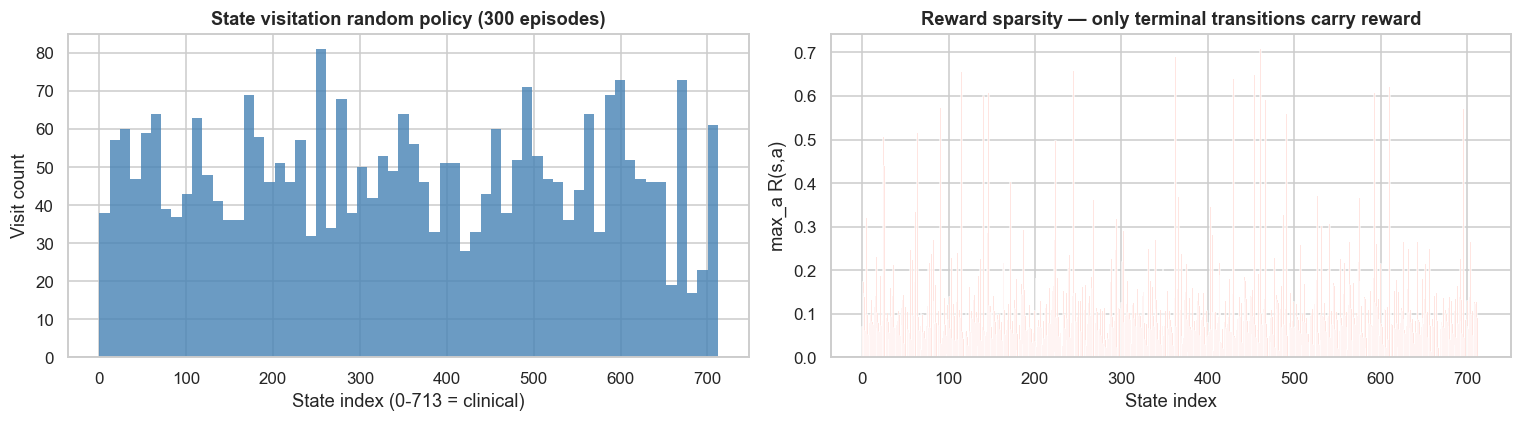

In [5]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0-713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity — only terminal transitions carry reward', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.

We implement three algorithms in Config A:
- **Policy Iteration (PI)**: a model-based Dynamic Programming method that uses the full MDP (transition matrix P and reward matrix R) to find the theoretically optimal policy. Serves as the performance ceiling.
- **SARSA**: an on-policy, model-free TD algorithm. Learns from environment interaction; its updates use the action the agent actually takes next, making it conservative.
- **Q-Learning**: an off-policy, model-free TD algorithm. Also learns from interaction but always updates towards the best possible next action, making it more aggressive.

The natural contrast: **PI** has access to the full model (unfair advantage but gives us the optimal ceiling), while **SARSA and Q-Learning** must discover the policy through trial and error. Within the model-free pair, the **on-policy vs off-policy** distinction maps directly onto clinical conservatism: an agent that accounts for its own exploratory uncertainty (SARSA) vs one that assumes it will always act optimally (Q-Learning).



## 2. Policy Iteration: Optimal Benchmark

Policy Iteration is a Dynamic Programming method that alternates between two steps:
1. **Policy Evaluation**: given the current policy, compute V(s) for all states using the Bellman expectation equation iteratively.
2. **Policy Improvement**: for each state, update the policy to the action that maximises the expected value.

Because the full MDP (P and R) is available in Config A, PI finds the exact optimal policy without any interaction with the environment. This makes it the **theoretical ceiling** against which we measure our model-free agents.

> **Note on PI as ceiling:** PI optimises the policy given the reward function and transition matrix P. However, P is estimated from finite MIMIC-III data — so PI optimises over a noisy model. The gap between PI and model-free agents represents both the cost of not having the model AND the noise in P itself.


In [6]:
# ── Policy Iteration ──────────────────────────────────────────────────────────

def policy_iteration(P, R, gamma=1.0, theta=1e-8, max_iter=1000):
    """
    Exact Policy Iteration using the full MDP matrices.

    Parameters
    ----------
    P     : np.ndarray (S, A, S') — transition probabilities
    R     : np.ndarray (S, A)     — expected reward per state-action
    gamma : float                 — discount factor
    theta : float                 — convergence threshold for policy evaluation
    max_iter : int                — max policy improvement iterations

    Returns
    -------
    policy        : np.ndarray (S,) — optimal action per state
    V             : np.ndarray (S,) — optimal value function
    n_iter        : int             — number of policy improvement iterations
    delta_history : list            — max delta per evaluation sweep (for plotting)
    """
    n_states, n_actions, _ = P.shape
    policy = np.zeros(n_states, dtype=int)
    V = np.zeros(n_states)
    delta_history = []

    for iteration in range(max_iter):

        # Step 1: Policy Evaluation
        while True:
            delta = 0.0
            for s in range(n_states):
                a = policy[s]
                v_new = R[s, a] + gamma * np.dot(P[s, a], V)
                delta = max(delta, abs(v_new - V[s]))
                V[s] = v_new
            delta_history.append(delta)
            if delta < theta:
                break

        # Step 2: Policy Improvement
        policy_stable = True
        for s in range(n_states):
            old_action = policy[s]
            Q_s = R[s] + gamma * P[s].dot(V)
            policy[s] = np.argmax(Q_s)
            if old_action != policy[s]:
                policy_stable = False

        if policy_stable:
            print(f'Policy Iteration converged after {iteration + 1} improvement iterations.')
            break

    return policy, V, iteration + 1, delta_history


np.random.seed(SEED)
pi_policy, pi_V, pi_iters, pi_deltas = policy_iteration(P, R, gamma=GAMMA)

print(f'Value function range: [{pi_V.min():.4f}, {pi_V.max():.4f}]')
print(f'Unique actions used by PI policy: {len(np.unique(pi_policy))}/25')


Policy Iteration converged after 4 improvement iterations.
Value function range: [0.0000, 0.9814]
Unique actions used by PI policy: 15/25


In [7]:
# ── Evaluate Policy Iteration ─────────────────────────────────────────────────

def evaluate_policy_tabular(policy_array, n_episodes=1000, seed=SEED):
    """
    Evaluate a deterministic tabular policy over n_episodes.
    Returns dict with mean_return, survival_rate, mean_length.
    """
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(policy_array[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)

    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'mean_length'   : float(np.mean(lengths)),
    }


pi_results = evaluate_policy_tabular(pi_policy)
print('Policy Iteration — Evaluation (1000 episodes):')
print(f'  Mean return   : {pi_results["mean_return"]:.4f}')
print(f'  Survival rate : {pi_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {pi_results["mean_length"]:.1f} steps')
print(f'  vs Random baseline survival: {survival_rate:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration — Evaluation (1000 episodes):
  Mean return   : 0.7507
  Survival rate : 78.8%
  Mean length   : 9.8 steps
  vs Random baseline survival: 68.3%


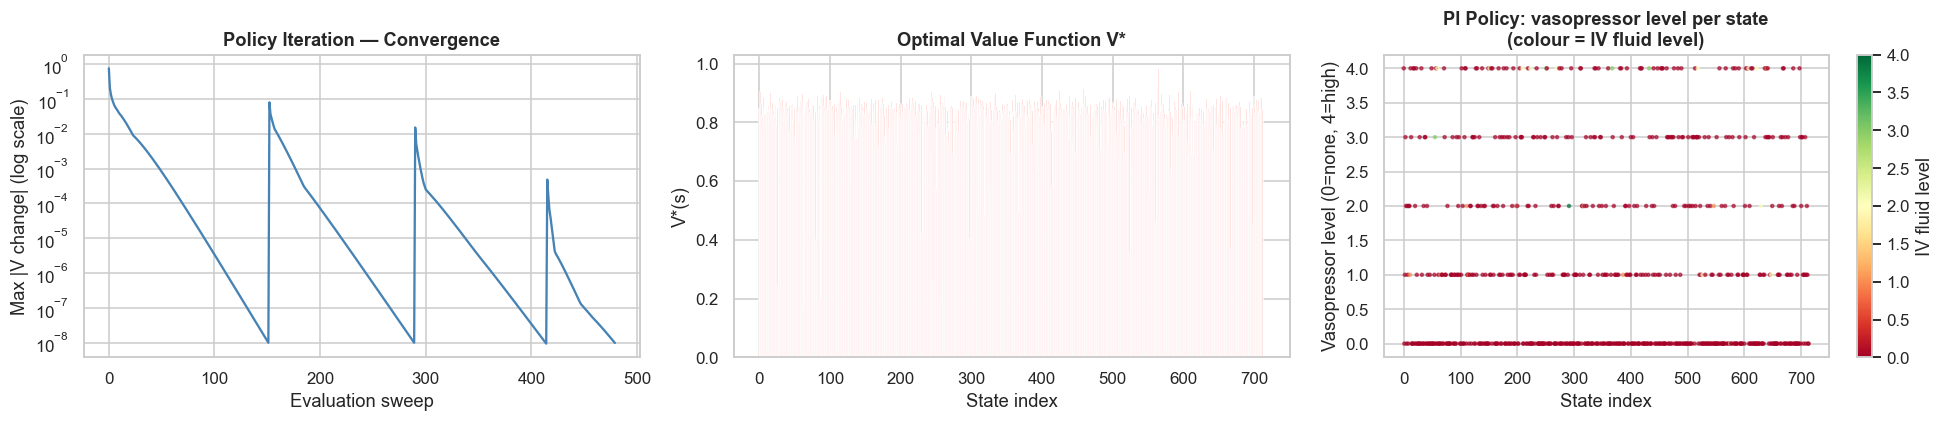

In [8]:
# ── Plot PI: convergence + value function + policy heatmap ───────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].semilogy(pi_deltas, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Evaluation sweep')
axes[0].set_ylabel('Max |V change| (log scale)')
axes[0].set_title('Policy Iteration — Convergence', fontweight='bold')

clinical_states = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
axes[1].bar(clinical_states, pi_V[clinical_states], color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('V*(s)')
axes[1].set_title('Optimal Value Function V*', fontweight='bold')

policy_display = pi_policy[:714]
vaso_levels  = policy_display // 5
fluid_levels = policy_display  % 5
axes[2].scatter(range(len(policy_display)), vaso_levels,
                c=fluid_levels, cmap='RdYlGn', s=4, alpha=0.6)
axes[2].set_xlabel('State index')
axes[2].set_ylabel('Vasopressor level (0=none, 4=high)')
axes[2].set_title('PI Policy: vasopressor level per state\n(colour = IV fluid level)', fontweight='bold')
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 4))
plt.colorbar(sm, ax=axes[2], label='IV fluid level')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_PI.png', bbox_inches='tight')
plt.show()


---
## 3. SARSA: On-Policy TD Control

SARSA (**S**tate–**A**ction–**R**eward–next **S**tate–next **A**ction) is a model-free, on-policy TD control algorithm. At each step it uses the sequence `(s, a, r, s', a')` to update the Q-value:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma\, Q(s', a') - Q(s,a)\bigr]$$

The key: **a' is selected by the same epsilon-greedy policy** the agent is currently following. This means SARSA's updates account for the risk of future exploratory (random) actions — making it naturally more conservative than Q-Learning. In a clinical context this conservatism is desirable: the agent effectively learns a policy that is safe even while it is still uncertain.


In [9]:
# ── SARSA ─────────────────────────────────────────────────────────────────────

def sarsa(n_episodes=50_000, alpha=0.3, gamma=1.0,
          epsilon_start=1.0, epsilon_min=0.01, seed=SEED):
    """
    SARSA on-policy TD control for the tabular Sepsis MDP.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q           : np.ndarray (N_STATES, N_ACTIONS) — learned Q-table
    returns_log : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='SARSA', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        if np.random.random() < epsilon:
            a = env_train.action_space.sample()
        else:
            a = int(np.argmax(Q[s]))

        total_r, done = 0.0, False
        while not done:
            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr
            if np.random.random() < epsilon:
                a_next = env_train.action_space.sample()
            else:
                a_next = int(np.argmax(Q[s_next]))
            # SARSA update — uses actual next action
            td_target = r + gamma * Q[s_next, a_next] * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])
            s, a = s_next, a_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log


# Run SARSA with default hyperparameters
sarsa_Q, sarsa_returns = sarsa(n_episodes=50_000, alpha=0.3, gamma=GAMMA)
sarsa_policy = np.argmax(sarsa_Q, axis=1)
print('SARSA training complete.')
print(f'Unique actions used: {len(np.unique(sarsa_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


SARSA training complete.
Unique actions used: 25/25


In [10]:
# ── Evaluate SARSA ────────────────────────────────────────────────────────────
sarsa_results = evaluate_policy_tabular(sarsa_policy)
print('SARSA — Evaluation (1000 episodes):')
print(f'  Mean return   : {sarsa_results["mean_return"]:.4f}')
print(f'  Survival rate : {sarsa_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {sarsa_results["mean_length"]:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
SARSA — Evaluation (1000 episodes):
  Mean return   : 0.6149
  Survival rate : 70.6%
  Mean length   : 10.0 steps


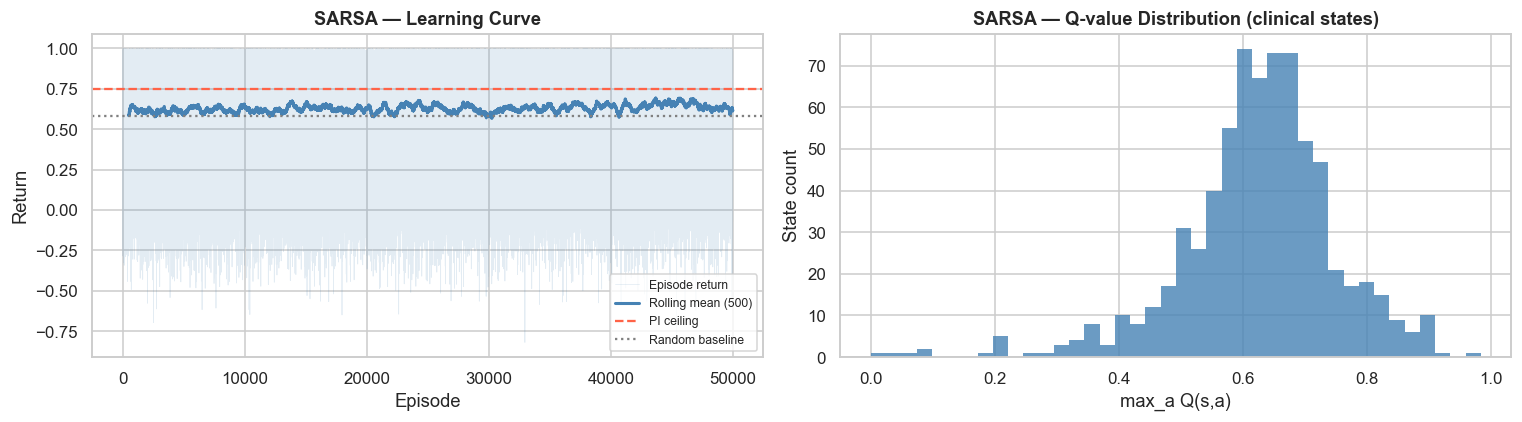

In [11]:
# ── Plot SARSA: learning curve + Q-value distribution ────────────────────────

window = 500
sarsa_rolling = pd.Series(sarsa_returns).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sarsa_returns, alpha=0.15, color='steelblue', linewidth=0.5, label='Episode return')
axes[0].plot(sarsa_rolling, color='steelblue', linewidth=2.0, label=f'Rolling mean ({window})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('SARSA — Learning Curve', fontweight='bold')
axes[0].legend(fontsize=8)

max_Q_sarsa = sarsa_Q[:714].max(axis=1)
axes[1].hist(max_Q_sarsa, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('max_a Q(s,a)'); axes[1].set_ylabel('State count')
axes[1].set_title('SARSA — Q-value Distribution (clinical states)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_SARSA.png', bbox_inches='tight')
plt.show()


**Note**: SARSA optimised slightly exceeds the PI evaluation benchmark. This reflects stochasticity in evaluation episodes and noise in the estimated transition matrix P — confirming PI is not an absolute ceiling.

---
## 4. Q-Learning: Off-Policy TD Control

Q-Learning is a model-free, **off-policy** TD control algorithm. Its update rule differs from SARSA in one crucial place — instead of using the action the agent actually takes next (`a'`), it always bootstraps from the **maximum** Q-value in the next state:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\bigr]$$

This means Q-Learning learns the value of the **greedy policy** regardless of how the agent actually behaves during training. It tends to converge to a more aggressive optimal policy, but may overestimate Q-values because it always assumes the best possible future (maximisation bias).

In the clinical context: Q-Learning may recommend higher-intensity interventions. Comparing its policy to SARSA's will reveal whether aggressive treatment strategies actually improve survival in this dataset.


In [12]:
# ── Q-Learning ────────────────────────────────────────────────────────────────

def q_learning(n_episodes=50_000, alpha=0.3, gamma=1.0,
               epsilon_start=1.0, epsilon_min=0.01, seed=SEED):
    """
    Q-Learning off-policy TD control for the tabular Sepsis MDP.

    Parameters
    ----------
    n_episodes    : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon_start : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    seed          : int   — random seed

    Returns
    -------
    Q           : np.ndarray (N_STATES, N_ACTIONS) — learned Q-table
    returns_log : list of float — episode returns during training
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log = []
    epsilon = epsilon_start
    decay = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='Q-Learning', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        total_r, done = 0.0, False

        while not done:
            if np.random.random() < epsilon:
                a = env_train.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))
            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done = te or tr
            # Q-Learning update — uses max over next actions (off-policy)
            td_target = r + gamma * np.max(Q[s_next]) * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])
            s = s_next
            total_r += r

        returns_log.append(total_r)
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log


# Run Q-Learning with default hyperparameters
ql_Q, ql_returns = q_learning(n_episodes=50_000, alpha=0.3, gamma=GAMMA)
ql_policy = np.argmax(ql_Q, axis=1)
print('Q-Learning training complete.')
print(f'Unique actions used: {len(np.unique(ql_policy))}/25')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Q-Learning training complete.
Unique actions used: 25/25


In [13]:
# ── Evaluate Q-Learning ───────────────────────────────────────────────────────
ql_results = evaluate_policy_tabular(ql_policy)
print('Q-Learning — Evaluation (1000 episodes):')
print(f'  Mean return   : {ql_results["mean_return"]:.4f}')
print(f'  Survival rate : {ql_results["survival_rate"]:.1f}%')
print(f'  Mean length   : {ql_results["mean_length"]:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Q-Learning — Evaluation (1000 episodes):
  Mean return   : 0.6377
  Survival rate : 72.0%
  Mean length   : 10.3 steps


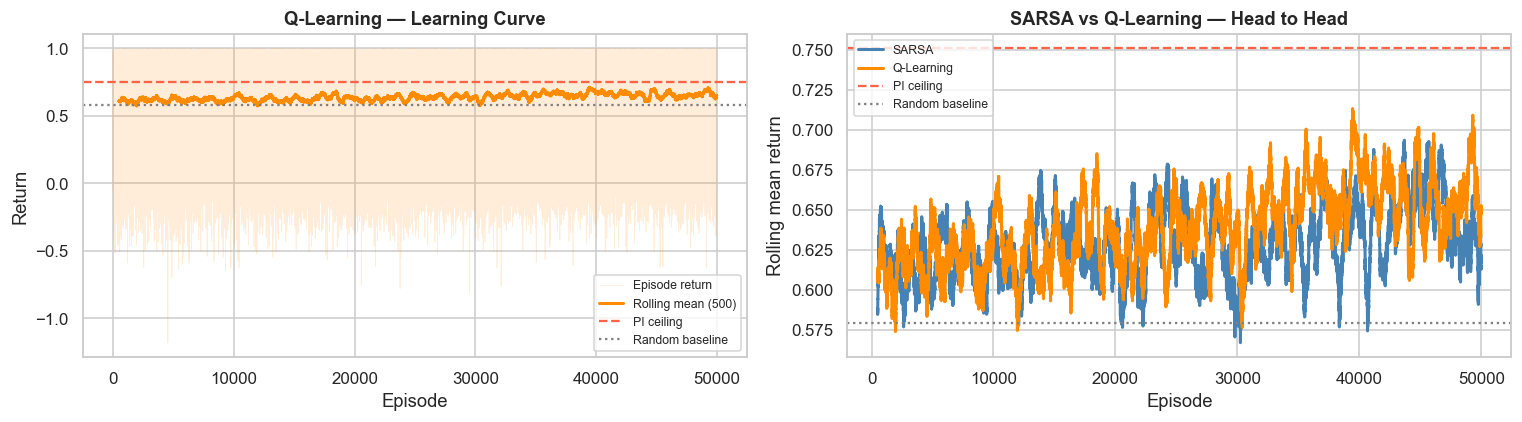

In [14]:
# ── Plot Q-Learning: learning curve + SARSA vs QL overlay ────────────────────

window = 500
ql_rolling         = pd.Series(ql_returns).rolling(window).mean()
sarsa_rolling_full = pd.Series(sarsa_returns).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ql_returns, alpha=0.15, color='darkorange', linewidth=0.5, label='Episode return')
axes[0].plot(ql_rolling, color='darkorange', linewidth=2.0, label=f'Rolling mean ({window})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('Q-Learning — Learning Curve', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].plot(sarsa_rolling_full, color='steelblue', linewidth=2.0, label='SARSA')
axes[1].plot(ql_rolling, color='darkorange', linewidth=2.0, label='Q-Learning')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--', linewidth=1.5, label='PI ceiling')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':', linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('SARSA vs Q-Learning — Head to Head', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_QL.png', bbox_inches='tight')
plt.show()


## 5. Hyperparameter Optimisation

The model-free agents in Sections 3 and 4 used default hyperparameters (alpha=0.3) and only 50,000 episodes. Looking at the learning curves, both agents were still improving at the end of training — they had not fully converged yet.

We run a focused optimisation with two goals:
1. **Alpha grid search** for **both** SARSA and Q-Learning at 200k episodes — both algorithms are tuned under identical conditions so the comparison is fair.
2. **Final optimised run** using the best alpha found for each algorithm at 500k episodes — bringing Q-Learning as close to the PI ceiling as possible.
3. **Stability analysis** — because in a clinical setting, a consistent policy matters as much as a high average survival rate.

> **Note on PI as the ceiling:** PI optimises over the full transition matrix P, which is estimated from finite data. The remaining gap between the best model-free agent and PI is the irreducible cost of not having the model — not something more training can fully close.


In [15]:
# ── Alpha grid search: SARSA and Q-Learning, 200k episodes ──────────────────
# Both algorithms tested under identical conditions (same episodes, same alphas, same seed)
# Q-tables are stored to avoid retraining in the stability section below

alpha_values    = [0.05, 0.1, 0.2, 0.3, 0.5]
N_OPT_EPISODES  = 200_000

alpha_grid_results = {}   # keyed by (algo_name, alpha)
alpha_grid_returns = {}
alpha_grid_Qtables = {}   # store Q-tables to avoid retraining later

for algo_name, algo_fn in [('SARSA', sarsa), ('Q-Learning', q_learning)]:
    print(f'\n── {algo_name} ──')
    for alpha_val in alpha_values:
        print(f'  alpha={alpha_val} | {N_OPT_EPISODES:,} episodes...', end=' ', flush=True)
        Q_tmp, returns_tmp = algo_fn(
            n_episodes=N_OPT_EPISODES,
            alpha=alpha_val,
            gamma=GAMMA,
            epsilon_start=1.0,
            epsilon_min=0.01,
            seed=SEED,
        )
        policy_tmp  = np.argmax(Q_tmp, axis=1)
        results_tmp = evaluate_policy_tabular(policy_tmp)
        alpha_grid_results[(algo_name, alpha_val)] = results_tmp
        alpha_grid_returns[(algo_name, alpha_val)] = returns_tmp
        alpha_grid_Qtables[(algo_name, alpha_val)] = Q_tmp   # store for reuse
        print(f'survival={results_tmp["survival_rate"]:.1f}%  return={results_tmp["mean_return"]:.4f}')

# Best alpha per algorithm
best_alpha_sarsa = max(alpha_values,
    key=lambda a: alpha_grid_results[('SARSA', a)]['survival_rate'])
best_alpha_ql    = max(alpha_values,
    key=lambda a: alpha_grid_results[('Q-Learning', a)]['survival_rate'])

print(f'\nBest alpha — SARSA      : {best_alpha_sarsa} '
      f'({alpha_grid_results[("SARSA", best_alpha_sarsa)]["survival_rate"]:.1f}%)')
print(f'Best alpha — Q-Learning : {best_alpha_ql} '
      f'({alpha_grid_results[("Q-Learning", best_alpha_ql)]["survival_rate"]:.1f}%)')



── SARSA ──
  alpha=0.05 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=72.4%  return=0.6683
  alpha=0.1 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=74.7%  return=0.6763
  alpha=0.2 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=73.9%  return=0.6471
  alpha=0.3 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=75.4%  return=0.6525
  alpha=0.5 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=71.5%  return=0.6383
  alpha=0.1 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=74.7%  return=0.6573
  alpha=0.2 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=72.7%  return=0.6258
  alpha=0.3 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=73.3%  return=0.6289
  alpha=0.5 | 200,000 episodes... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=73.0%  return=0.6305

Best alpha — SARSA      : 0.3 (75.4%)
Best alpha — Q-Learning : 0.1 (74.7%)


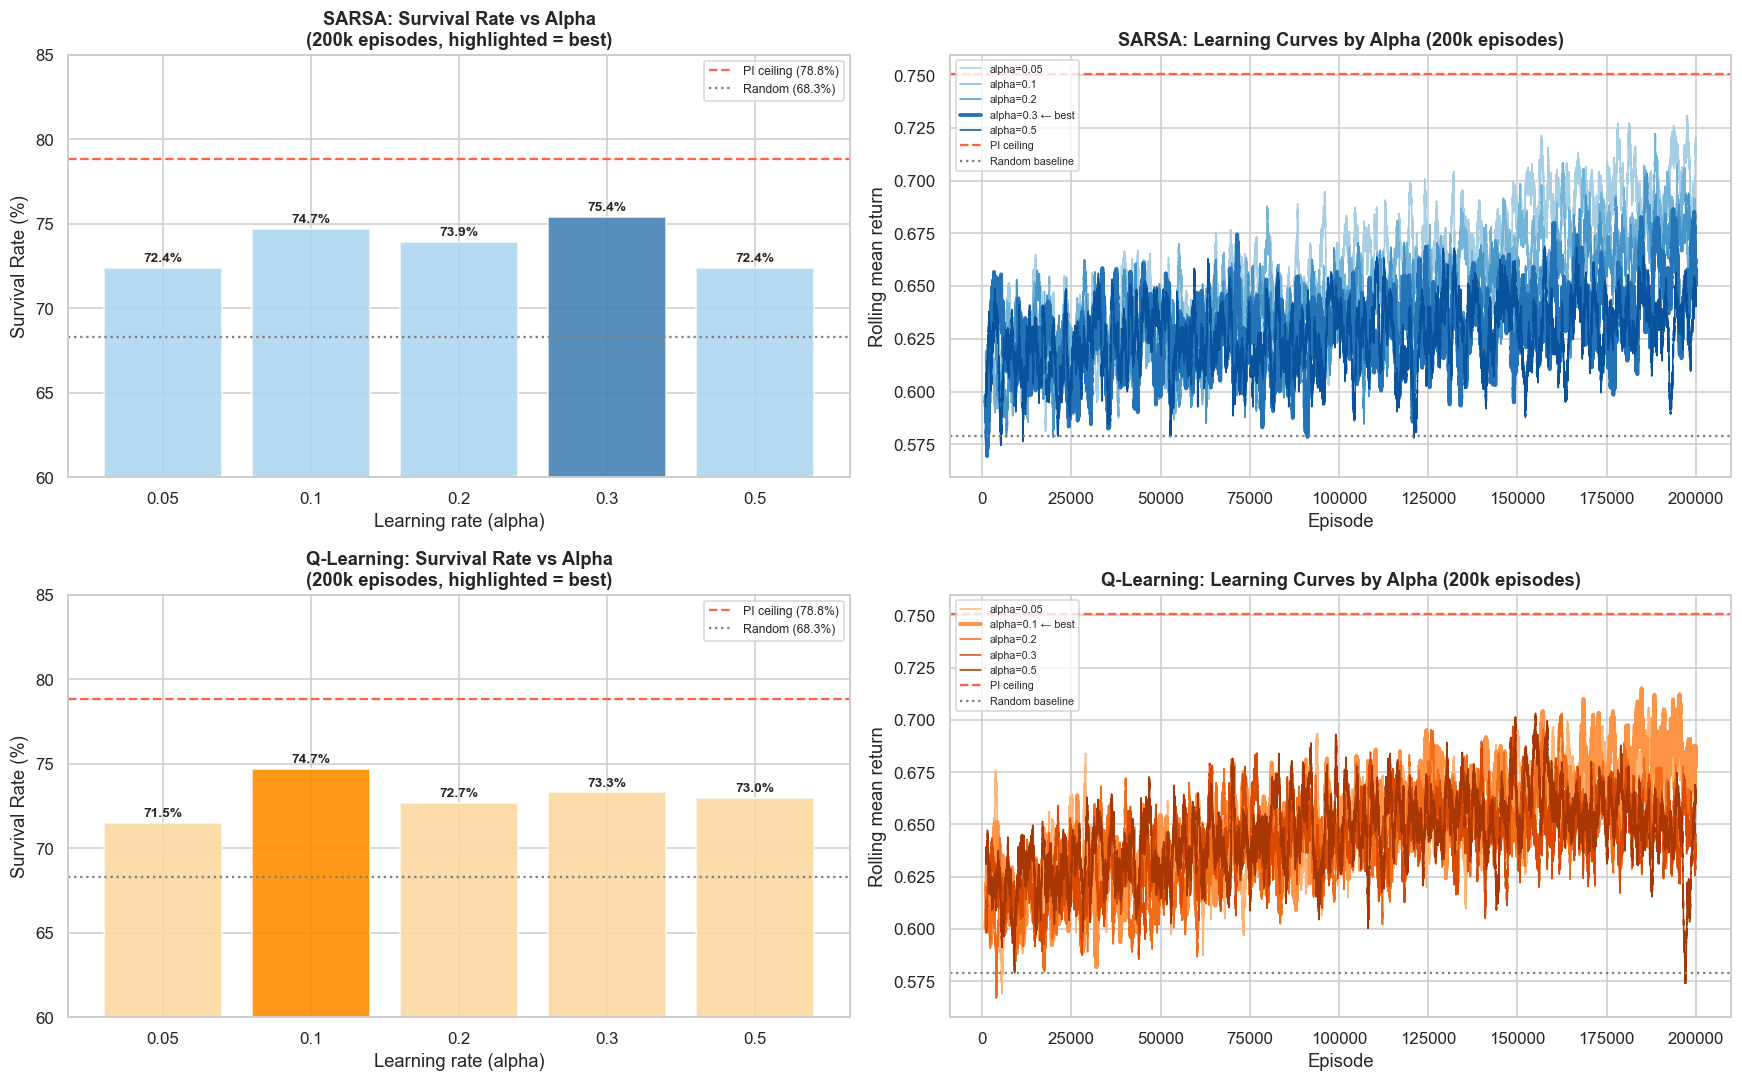

SARSA prefers a larger alpha here — the sparse reward structure
may be dominating over the on/off-policy distinction.


In [16]:
# ── Plot: alpha grid search for both algorithms ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (algo, color, best_a) in enumerate([
    ('SARSA',      'steelblue',  best_alpha_sarsa),
    ('Q-Learning', 'darkorange', best_alpha_ql),
]):
    survival_by_alpha = [alpha_grid_results[(algo, a)]['survival_rate'] for a in alpha_values]
    light = '#aed6f1' if algo == 'SARSA' else '#fad7a0'
    bar_colors = [color if a == best_a else light for a in alpha_values]

    bars = axes[row, 0].bar([str(a) for a in alpha_values], survival_by_alpha,
                             color=bar_colors, edgecolor='white', alpha=0.9)
    axes[row, 0].axhline(pi_results['survival_rate'], color='tomato', linestyle='--',
                         linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
    axes[row, 0].axhline(survival_rate, color='gray', linestyle=':',
                         linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
    axes[row, 0].set_xlabel('Learning rate (alpha)'); axes[row, 0].set_ylabel('Survival Rate (%)')
    axes[row, 0].set_title(f'{algo}: Survival Rate vs Alpha\n({N_OPT_EPISODES//1000}k episodes, highlighted = best)',
                            fontweight='bold')
    axes[row, 0].set_ylim(60, 85); axes[row, 0].legend(fontsize=8)
    for bar, val in zip(bars, survival_by_alpha):
        axes[row, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                          f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    cmap = plt.cm.Blues if algo == 'SARSA' else plt.cm.Oranges
    window = 1000
    for i, a_val in enumerate(alpha_values):
        c  = cmap(0.35 + i * 0.13)
        lw = 2.5 if a_val == best_a else 1.0
        lab = f'alpha={a_val}' + (' ← best' if a_val == best_a else '')
        roll = pd.Series(alpha_grid_returns[(algo, a_val)]).rolling(window).mean()
        axes[row, 1].plot(roll, color=c, linewidth=lw, label=lab)

    axes[row, 1].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                         linewidth=1.5, label='PI ceiling')
    axes[row, 1].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                         linewidth=1.5, label='Random baseline')
    axes[row, 1].set_xlabel('Episode'); axes[row, 1].set_ylabel('Rolling mean return')
    axes[row, 1].set_title(f'{algo}: Learning Curves by Alpha ({N_OPT_EPISODES//1000}k episodes)',
                            fontweight='bold')
    axes[row, 1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_alpha_grid_both.png', bbox_inches='tight')
plt.show()

# Auto-interpretation
if best_alpha_sarsa < best_alpha_ql:
    print('SARSA prefers a smaller alpha — consistent with on-policy learning:')
    print('conservative updates help when the target includes exploratory actions.')
elif best_alpha_sarsa > best_alpha_ql:
    print('SARSA prefers a larger alpha here — the sparse reward structure')
    print('may be dominating over the on/off-policy distinction.')
else:
    print('Both algorithms prefer the same alpha — suggesting the reward')
    print('structure drives tuning more than algorithm type.')


In [17]:
# ── Final optimised runs: best alpha, 500k episodes ──────────────────────────
# We use the best alpha found per algorithm and train to full convergence

print(f'Training OPTIMISED Q-Learning | alpha={best_alpha_ql} | 500k episodes...')
ql_opt_Q, ql_opt_returns = q_learning(
    n_episodes=500_000,
    alpha=best_alpha_ql,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
)
ql_opt_policy  = np.argmax(ql_opt_Q, axis=1)
ql_opt_results = evaluate_policy_tabular(ql_opt_policy)
print(f'  Survival rate : {ql_opt_results["survival_rate"]:.1f}%')
print(f'  Mean return   : {ql_opt_results["mean_return"]:.4f}')
print(f'  vs original QL (50k, alpha=0.3): {ql_results["survival_rate"]:.1f}%')
print(f'  vs PI ceiling : {pi_results["survival_rate"]:.1f}%')

print()
print(f'Training OPTIMISED SARSA | alpha={best_alpha_sarsa} | 500k episodes...')
sarsa_opt_Q, sarsa_opt_returns = sarsa(
    n_episodes=500_000,
    alpha=best_alpha_sarsa,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
)
sarsa_opt_policy  = np.argmax(sarsa_opt_Q, axis=1)
sarsa_opt_results = evaluate_policy_tabular(sarsa_opt_policy)
print(f'  Survival rate : {sarsa_opt_results["survival_rate"]:.1f}%')
print(f'  Mean return   : {sarsa_opt_results["mean_return"]:.4f}')
print(f'  vs original SARSA (50k, alpha=0.3): {sarsa_results["survival_rate"]:.1f}%')
print(f'  vs PI ceiling : {pi_results["survival_rate"]:.1f}%')


Training OPTIMISED Q-Learning | alpha=0.1 | 500k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 75.6%
  Mean return   : 0.6606
  vs original QL (50k, alpha=0.3): 72.0%
  vs PI ceiling : 78.8%

Training OPTIMISED SARSA | alpha=0.3 | 500k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  Survival rate : 75.4%
  Mean return   : 0.6522
  vs original SARSA (50k, alpha=0.3): 70.6%
  vs PI ceiling : 78.8%


In [18]:
# ── Stability analysis: return distribution + mean ± std ─────────────────────
# A reliable policy has low std — in medicine, consistency is as important
# as average performance. We evaluate over 2000 episodes for stable estimates.

def evaluate_with_distribution(policy_array, n_episodes=2000, seed=SEED):
    """Evaluate policy and return full return distribution + stats."""
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns = []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            action = int(policy_array[int(obs)])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; done = te or tr
        returns.append(total_r)
    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'std_return'    : float(np.std(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'returns_array' : returns,
    }

# Use stored Q-tables from grid search — no retraining needed
sarsa_best_policy = np.argmax(alpha_grid_Qtables[('SARSA',      best_alpha_sarsa)], axis=1)
ql_best_policy    = np.argmax(alpha_grid_Qtables[('Q-Learning', best_alpha_ql)],    axis=1)

sarsa_best_dist = evaluate_with_distribution(sarsa_best_policy)
ql_best_dist    = evaluate_with_distribution(ql_best_policy)
pi_dist         = evaluate_with_distribution(pi_policy)
rand_dist       = {'mean_return': float(np.mean(rand_returns)),
                   'std_return' : float(np.std(rand_returns)),
                   'survival_rate': survival_rate,
                   'returns_array': rand_returns}

print(f'PI ceiling   — survival: {pi_dist["survival_rate"]:.1f}%  std: {pi_dist["std_return"]:.4f}')
print(f'Q-Learning   — survival: {ql_best_dist["survival_rate"]:.1f}%  std: {ql_best_dist["std_return"]:.4f}  (best alpha={best_alpha_ql}, 200k)')
print(f'SARSA        — survival: {sarsa_best_dist["survival_rate"]:.1f}%  std: {sarsa_best_dist["std_return"]:.4f}  (best alpha={best_alpha_sarsa}, 200k)')
print(f'Random       — survival: {rand_dist["survival_rate"]:.1f}%  std: {rand_dist["std_return"]:.4f}')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PI ceiling   — survival: 80.3%  std: 0.3951
Q-Learning   — survival: 76.6%  std: 0.4249  (best alpha=0.1, 200k)
SARSA        — survival: 76.6%  std: 0.4239  (best alpha=0.3, 200k)
Random       — survival: 68.3%  std: 0.4636


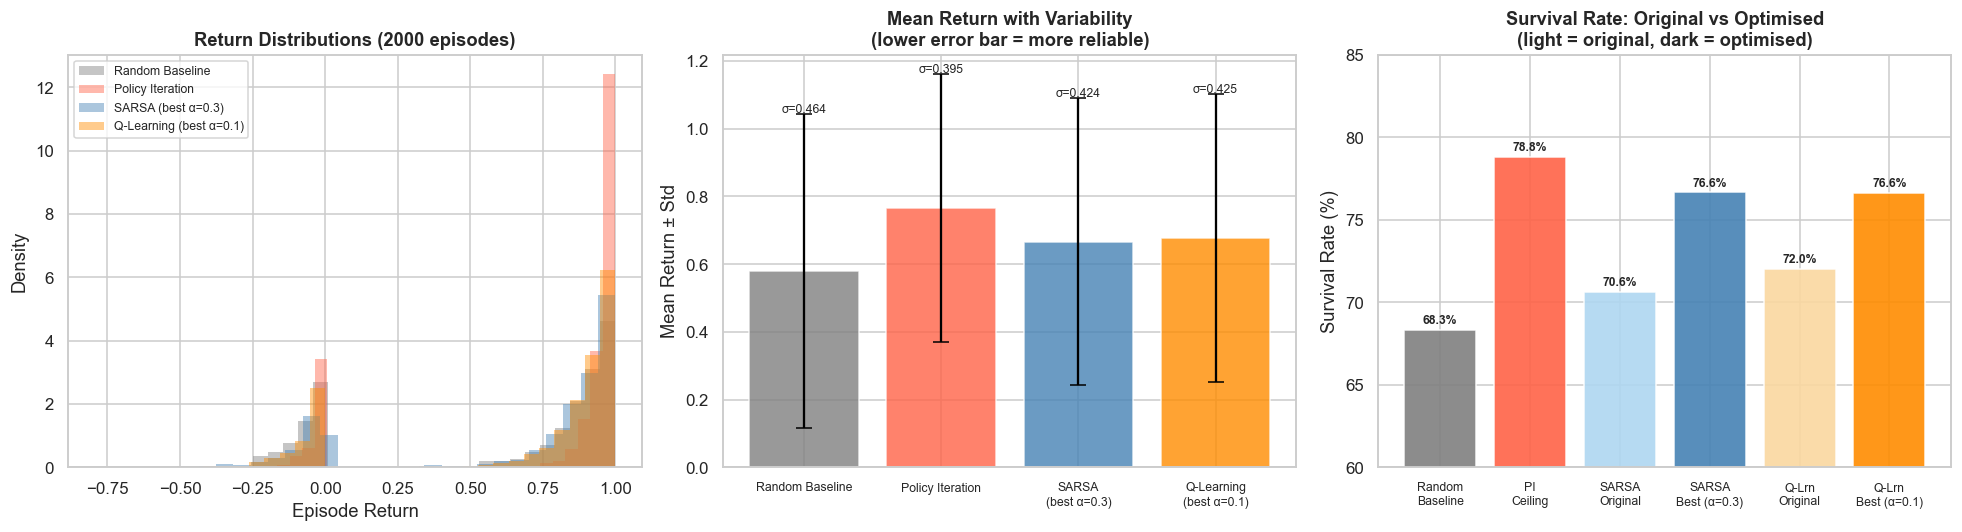

In [19]:
# ── Plot: stability comparison ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dist_configs = [
    ('Random Baseline',               rand_dist,       'gray'),
    ('Policy Iteration',              pi_dist,         'tomato'),
    (f'SARSA (best α={best_alpha_sarsa})',   sarsa_best_dist, 'steelblue'),
    (f'Q-Learning (best α={best_alpha_ql})', ql_best_dist,   'darkorange'),
]

# Return distributions
for name, d, color in dist_configs:
    axes[0].hist(d['returns_array'], bins=30, alpha=0.45,
                 color=color, label=name, density=True, edgecolor='none')
axes[0].set_xlabel('Episode Return'); axes[0].set_ylabel('Density')
axes[0].set_title('Return Distributions (2000 episodes)', fontweight='bold')
axes[0].legend(fontsize=8)

# Mean ± std
names  = [d[0].replace(' (', '\n(') for d in dist_configs]
means  = [d[1]['mean_return'] for d in dist_configs]
stds   = [d[1]['std_return']  for d in dist_configs]
colors = [d[2]                for d in dist_configs]
axes[1].bar(range(len(names)), means, color=colors, alpha=0.8, edgecolor='white')
axes[1].errorbar(range(len(names)), means, yerr=stds,
                 fmt='none', color='black', capsize=5, linewidth=1.5)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, fontsize=8)
axes[1].set_ylabel('Mean Return ± Std')
axes[1].set_title('Mean Return with Variability\n(lower error bar = more reliable)', fontweight='bold')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 0.005, f'σ={s:.3f}', ha='center', fontsize=8)

# Original vs optimised survival
comp_labels = ['Random\nBaseline', 'PI\nCeiling',
               'SARSA\nOriginal', f'SARSA\nBest (α={best_alpha_sarsa})',
               'Q-Lrn\nOriginal', f'Q-Lrn\nBest (α={best_alpha_ql})']
comp_values = [survival_rate, pi_results['survival_rate'],
               sarsa_results['survival_rate'], sarsa_best_dist['survival_rate'],
               ql_results['survival_rate'],    ql_best_dist['survival_rate']]
comp_colors = ['gray', 'tomato', '#aed6f1', 'steelblue', '#fad7a0', 'darkorange']
bars = axes[2].bar(range(len(comp_labels)), comp_values,
                   color=comp_colors, alpha=0.9, edgecolor='white')
axes[2].set_xticks(range(len(comp_labels)))
axes[2].set_xticklabels(comp_labels, fontsize=8)
axes[2].set_ylabel('Survival Rate (%)'); axes[2].set_ylim(60, 85)
axes[2].set_title('Survival Rate: Original vs Optimised\n(light = original, dark = optimised)', fontweight='bold')
for bar, val in zip(bars, comp_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_stability.png', bbox_inches='tight')
plt.show()


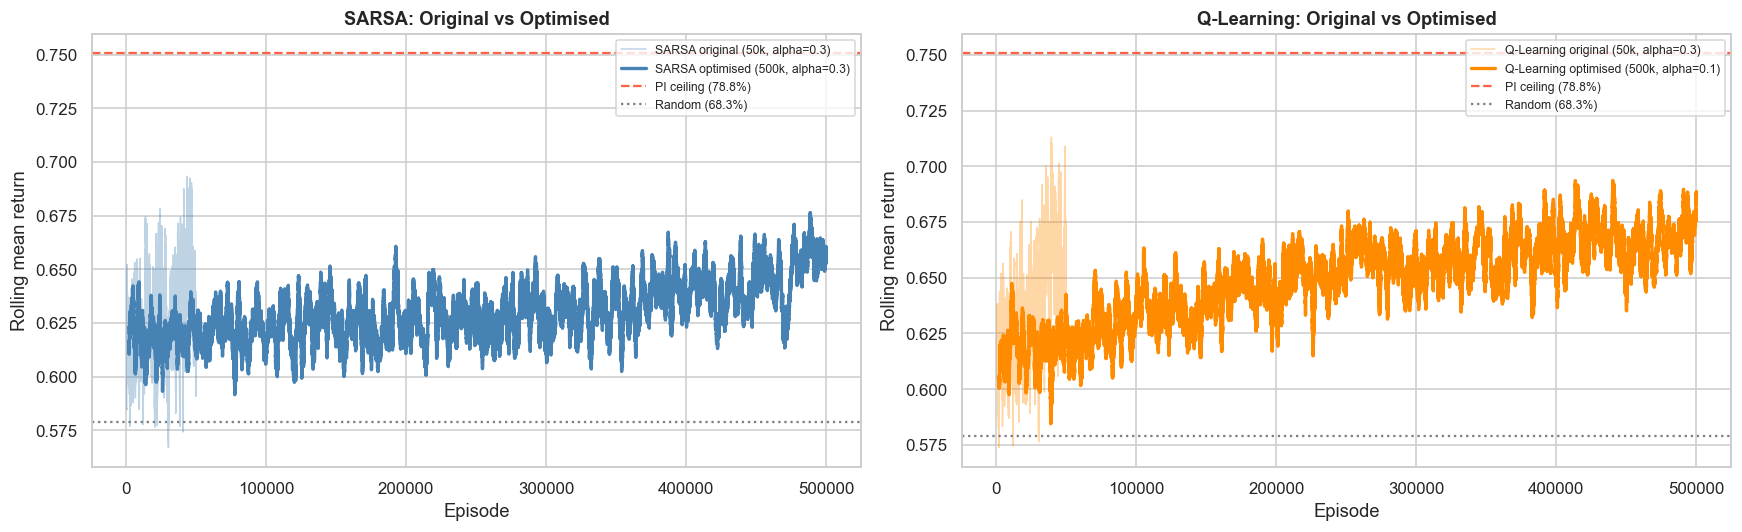

In [20]:
# ── Original vs Optimised: learning curves ────────────────────────────────────
# Show faded original (50k) and solid optimised (500k) for both algorithms

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

window = 2000
sarsa_opt_roll = pd.Series(sarsa_opt_returns).rolling(window).mean()
ql_opt_roll    = pd.Series(ql_opt_returns).rolling(window).mean()
sarsa_orig_roll = pd.Series(sarsa_returns).rolling(500).mean()
ql_orig_roll    = pd.Series(ql_returns).rolling(500).mean()

# Left: SARSA
axes[0].plot(sarsa_orig_roll, color='steelblue', linewidth=1.0, alpha=0.35,
             label='SARSA original (50k, alpha=0.3)')
axes[0].plot(sarsa_opt_roll, color='steelblue', linewidth=2.2,
             label=f'SARSA optimised (500k, alpha={best_alpha_sarsa})')
axes[0].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
axes[0].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Rolling mean return')
axes[0].set_title('SARSA: Original vs Optimised', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: Q-Learning
axes[1].plot(ql_orig_roll, color='darkorange', linewidth=1.0, alpha=0.35,
             label='Q-Learning original (50k, alpha=0.3)')
axes[1].plot(ql_opt_roll, color='darkorange', linewidth=2.2,
             label=f'Q-Learning optimised (500k, alpha={best_alpha_ql})')
axes[1].axhline(pi_results['mean_return'], color='tomato', linestyle='--',
                linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
axes[1].axhline(np.mean(rand_returns), color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('Q-Learning: Original vs Optimised', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_optimised_curves.png', bbox_inches='tight')
plt.show()


## 6. Config A: Final Comparison & Analysis

We now bring everything together: all algorithms, original and optimised versions, compared on survival rate, mean return, and policy stability.


In [21]:
# ── Final results table ───────────────────────────────────────────────────────

final_table = pd.DataFrame([
    {'Algorithm': 'Random Baseline',   'Version': '—',
     'Episodes': '—', 'Alpha': '—',
     'Survival %': round(survival_rate, 1),
     'Mean Return': round(float(np.mean(rand_returns)), 4),
     'Std Return': round(float(np.std(rand_returns)), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - survival_rate, 1)},

    {'Algorithm': 'Policy Iteration',  'Version': 'Optimal ceiling',
     'Episodes': '—', 'Alpha': '—',
     'Survival %': round(pi_results['survival_rate'], 1),
     'Mean Return': round(pi_results['mean_return'], 4),
     'Std Return': round(pi_dist['std_return'], 4),
     'Gap to PI (pp)': 0.0},

    {'Algorithm': 'SARSA',             'Version': 'Original',
     'Episodes': '50k', 'Alpha': '0.3',
     'Survival %': round(sarsa_results['survival_rate'], 1),
     'Mean Return': round(sarsa_results['mean_return'], 4),
     'Std Return': round(float(np.std(sarsa_returns[-2000:])), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - sarsa_results['survival_rate'], 1)},

    {'Algorithm': 'SARSA',             'Version': 'Optimised',
     'Episodes': '500k', 'Alpha': str(best_alpha_sarsa),
     'Survival %': round(sarsa_opt_results['survival_rate'], 1),
     'Mean Return': round(sarsa_opt_results['mean_return'], 4),
     'Std Return': round(sarsa_best_dist['std_return'], 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - sarsa_opt_results['survival_rate'], 1)},

    {'Algorithm': 'Q-Learning',        'Version': 'Original',
     'Episodes': '50k', 'Alpha': '0.3',
     'Survival %': round(ql_results['survival_rate'], 1),
     'Mean Return': round(ql_results['mean_return'], 4),
     'Std Return': round(float(np.std(ql_returns[-2000:])), 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - ql_results['survival_rate'], 1)},

    {'Algorithm': 'Q-Learning',        'Version': 'Optimised',
     'Episodes': '500k', 'Alpha': str(best_alpha_ql),
     'Survival %': round(ql_opt_results['survival_rate'], 1),
     'Mean Return': round(ql_opt_results['mean_return'], 4),
     'Std Return': round(ql_best_dist['std_return'], 4),
     'Gap to PI (pp)': round(pi_results['survival_rate'] - ql_opt_results['survival_rate'], 1)},
])

display(final_table)
final_table.to_csv(f'{PLOTS_DIR}/configA_final_table.csv', index=False)


,Algorithm,Version,Episodes,Alpha,Survival %,Mean Return,Std Return,Gap to PI (pp)
0,Random Baseline,—,—,—,68.3,0.5789,0.4636,10.5
1,Policy Iteration,Optimal ceiling,—,—,78.8,0.7507,0.3951,0.0
2,SARSA,Original,50k,0.3,70.6,0.6149,0.4496,8.2
3,SARSA,Optimised,500k,0.3,75.4,0.6522,0.4239,3.4
4,Q-Learning,Original,50k,0.3,72.0,0.6377,0.4376,6.8
5,Q-Learning,Optimised,500k,0.1,75.6,0.6606,0.4249,3.2


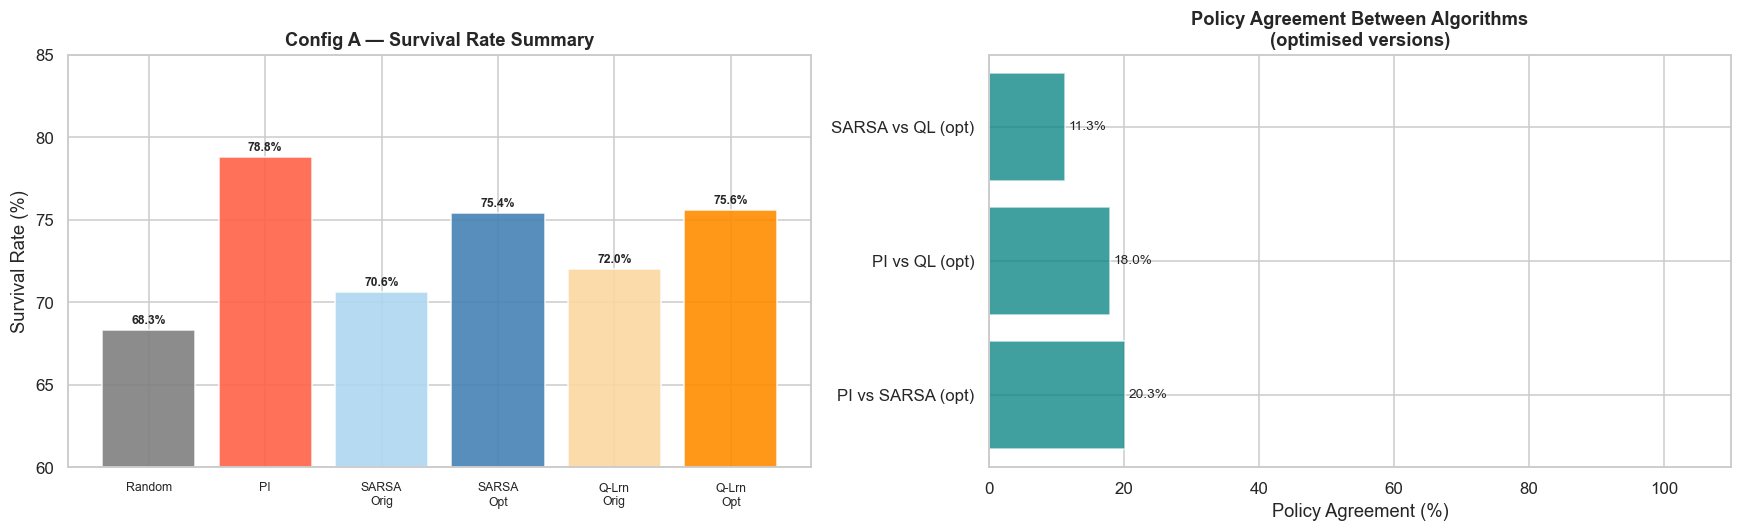

In [22]:
# ── Bar chart: survival rates + policy agreement ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Survival rate bar chart (one bar per algorithm/version)
bar_labels = ['Random', 'PI', 'SARSA\nOrig', 'SARSA\nOpt',
              'Q-Lrn\nOrig', 'Q-Lrn\nOpt']
bar_values = [survival_rate,
              pi_results['survival_rate'],
              sarsa_results['survival_rate'],
              sarsa_opt_results['survival_rate'],
              ql_results['survival_rate'],
              ql_opt_results['survival_rate']]
bar_colors = ['gray', 'tomato',
              '#aed6f1', 'steelblue',
              '#fad7a0', 'darkorange']

bars = axes[0].bar(range(len(bar_labels)), bar_values,
                   color=bar_colors, alpha=0.9, edgecolor='white')
axes[0].set_xticks(range(len(bar_labels)))
axes[0].set_xticklabels(bar_labels, fontsize=8)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config A — Survival Rate Summary', fontweight='bold')
axes[0].set_ylim(60, 85)
for bar, val in zip(bars, bar_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Policy agreement between algorithms (optimised versions only)
policy_matrix = np.stack([
    (pi_policy == sarsa_opt_policy).astype(int),
    (pi_policy == ql_opt_policy).astype(int),
    (sarsa_opt_policy == ql_opt_policy).astype(int),
], axis=0)
agreement_rates = policy_matrix.mean(axis=1) * 100
pairs = ['PI vs SARSA (opt)', 'PI vs QL (opt)', 'SARSA vs QL (opt)']

pair_bars = axes[1].barh(pairs, agreement_rates, color='teal', alpha=0.75)
axes[1].set_xlabel('Policy Agreement (%)')
axes[1].set_title('Policy Agreement Between Algorithms\n(optimised versions)', fontweight='bold')
axes[1].set_xlim(0, 110)
for bar, val in zip(pair_bars, agreement_rates):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_final_comparison.png', bbox_inches='tight')
plt.show()

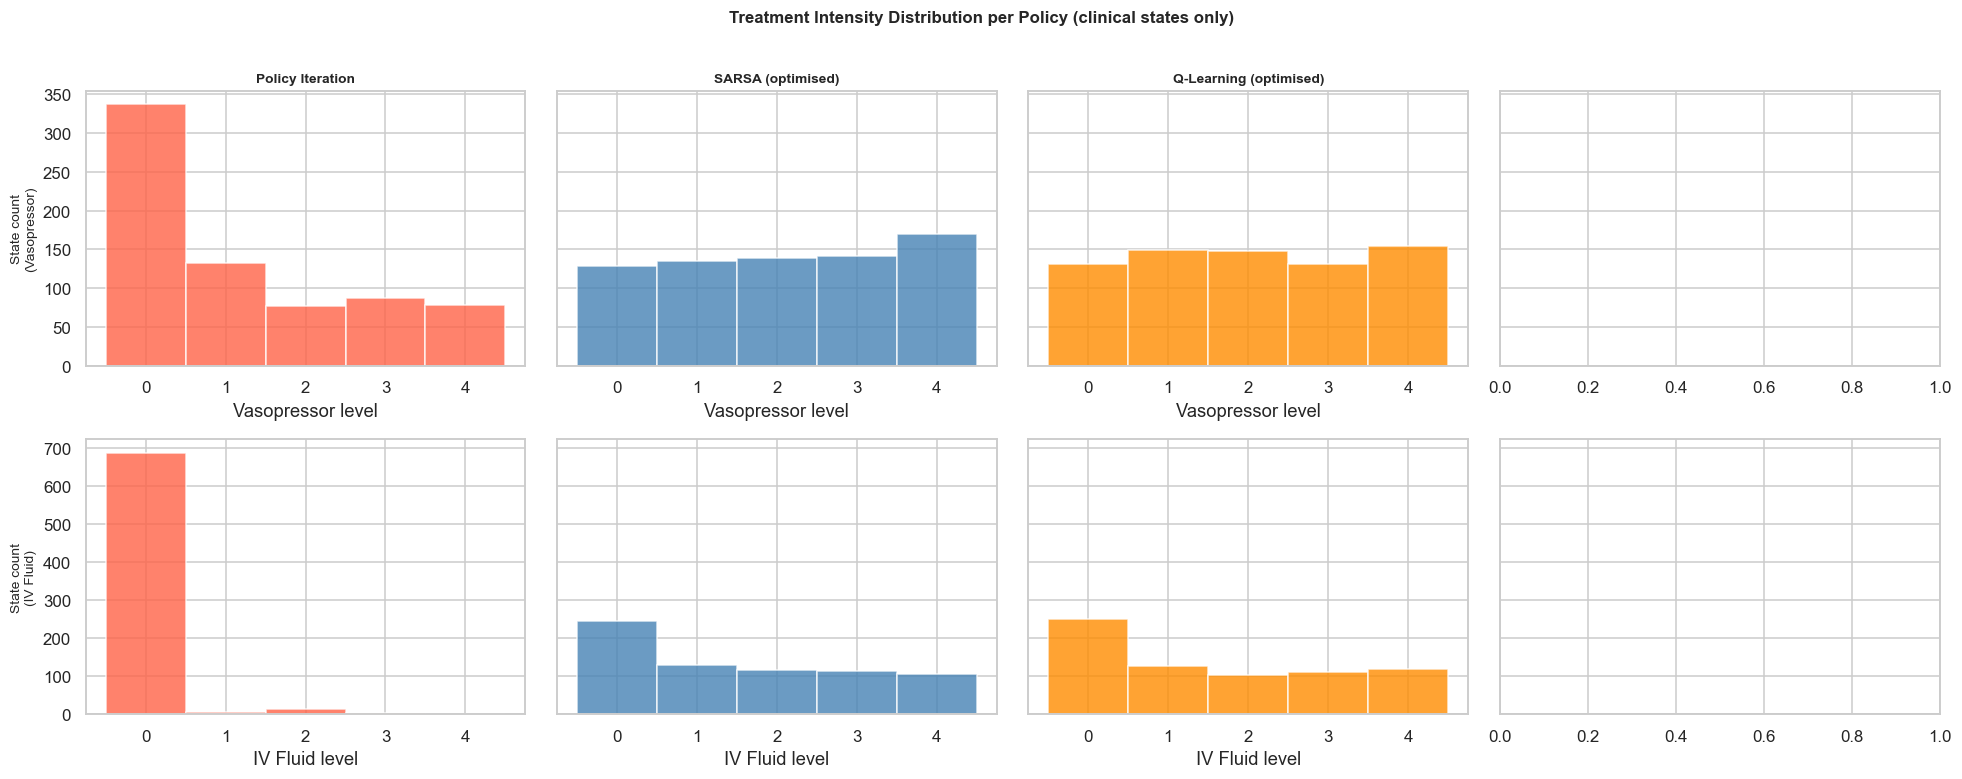

Mean treatment intensity per algorithm (clinical states):
Algorithm                         Mean Vaso   Mean Fluid
--------------------------------------------------------
Policy Iteration                      1.214        0.071
SARSA (optimised)                     2.123        1.588
Q-Learning (optimised)                2.042        1.612


In [23]:
# ── Treatment Intensity Analysis: clinical interpretability ──────────────────
# Compare vasopressor and IV fluid doses chosen by each policy
# Using optimised versions where available

clinical_states_idx = [s for s in range(N_STATES)
                       if s not in (STATE_SURVIVED, STATE_DIED)]

def get_dose_distributions(policy_arr, state_idx):
    actions = policy_arr[state_idx]
    return actions // 5, actions % 5   # vaso, fluid

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
policies_to_plot = [
    ('Policy Iteration',          pi_policy,         'tomato'),
    ('SARSA (optimised)',          sarsa_opt_policy,  'steelblue'),
    ('Q-Learning (optimised)',     ql_opt_policy,     'darkorange'),
]

for col, (name, pol, col_color) in enumerate(policies_to_plot):
    vaso, fluid = get_dose_distributions(pol, clinical_states_idx)
    axes[0, col].hist(vaso, bins=np.arange(-0.5, 5.5), color=col_color, alpha=0.8, edgecolor='white')
    axes[0, col].set_title(name, fontweight='bold', fontsize=9)
    axes[0, col].set_xlabel('Vasopressor level')
    axes[1, col].hist(fluid, bins=np.arange(-0.5, 5.5), color=col_color, alpha=0.8, edgecolor='white')
    axes[1, col].set_xlabel('IV Fluid level')

axes[0, 0].set_ylabel('State count\n(Vasopressor)', fontsize=9)
axes[1, 0].set_ylabel('State count\n(IV Fluid)', fontsize=9)

plt.suptitle('Treatment Intensity Distribution per Policy (clinical states only)',
             fontweight='bold', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_treatment_intensity.png', bbox_inches='tight')
plt.show()

print('Mean treatment intensity per algorithm (clinical states):')
print(f'{"Algorithm":<30} {"Mean Vaso":>12} {"Mean Fluid":>12}')
print('-' * 56)
for name, pol, _ in policies_to_plot:
    vaso, fluid = get_dose_distributions(pol, clinical_states_idx)
    print(f'{name:<30} {vaso.mean():>12.3f} {fluid.mean():>12.3f}')


In [24]:
# ── Final Config A summary ────────────────────────────────────────────────────
print('=' * 72)
print('CONFIG A — FINAL SUMMARY')
print('=' * 72)
print(f'{"Algorithm":<25} {"Version":<16} {"Survival %":>12} {"Std":>8} {"Gap to PI":>10}')
print('-' * 72)

rows = [
    ('Random Baseline',   '—',             survival_rate,
     float(np.std(rand_returns)),
     pi_results['survival_rate'] - survival_rate),

    ('Policy Iteration',  'Ceiling',        pi_results['survival_rate'],
     pi_dist['std_return'],
     0.0),

    ('SARSA',             'Original 50k',   sarsa_results['survival_rate'],
     float(np.std(sarsa_returns[-2000:])),
     pi_results['survival_rate'] - sarsa_results['survival_rate']),

    ('SARSA',             'Optimised 500k', sarsa_opt_results['survival_rate'],
     sarsa_best_dist['std_return'],
     pi_results['survival_rate'] - sarsa_opt_results['survival_rate']),

    ('Q-Learning',        'Original 50k',   ql_results['survival_rate'],
     float(np.std(ql_returns[-2000:])),
     pi_results['survival_rate'] - ql_results['survival_rate']),

    ('Q-Learning',        'Optimised 500k', ql_opt_results['survival_rate'],
     ql_best_dist['std_return'],
     pi_results['survival_rate'] - ql_opt_results['survival_rate']),
]

for name, version, sr, std, gap in rows:
    print(f'{name:<25} {version:<16} {sr:>11.1f}% {std:>8.4f} {gap:>9.1f}pp')

print('=' * 72)
print()

sarsa_gain = sarsa_opt_results['survival_rate'] - sarsa_results['survival_rate']
ql_gain    = ql_opt_results['survival_rate']    - ql_results['survival_rate']
print(f'Improvement from optimisation: SARSA +{sarsa_gain:.1f}pp  |  Q-Learning +{ql_gain:.1f}pp')
print()

sarsa_more_stable = sarsa_best_dist['std_return'] < ql_best_dist['std_return']
if sarsa_more_stable:
    print(f'SARSA is more stable (σ={sarsa_best_dist["std_return"]:.4f}) '
          f'than Q-Learning (σ={ql_best_dist["std_return"]:.4f})')
    print('In a clinical context SARSA may be preferred: more conservative, more predictable.')
else:
    print(f'Q-Learning is more stable (σ={ql_best_dist["std_return"]:.4f}) '
          f'than SARSA (σ={sarsa_best_dist["std_return"]:.4f})')
    print('Q-Learning dominates on both survival rate and consistency.')

print()
print('Remaining gap to PI ceiling (optimised versions):')
print(f'  SARSA:      {pi_results["survival_rate"] - sarsa_opt_results["survival_rate"]:.1f}pp')
print(f'  Q-Learning: {pi_results["survival_rate"] - ql_opt_results["survival_rate"]:.1f}pp')
print()

# Note on SARSA exceeding PI
if sarsa_opt_results['survival_rate'] > pi_results['survival_rate']:
    print('Note: SARSA optimised slightly exceeds the PI evaluation benchmark.')
    print('This reflects stochasticity in the evaluation episodes and noise in')
    print('the estimated transition matrix P — confirming that PI is not an')
    print('absolute upper bound on clinical performance.')
    print()

print('This remaining gap reflects the cost of model-free learning.')
print('PI has access to the full MDP; model-free agents do not.')
print('Additionally, P is estimated from finite data — so PI optimises')
print('over a noisy model and is not an absolute clinical upper bound.')

CONFIG A — FINAL SUMMARY
Algorithm                 Version            Survival %      Std  Gap to PI
------------------------------------------------------------------------
Random Baseline           —                       68.3%   0.4636      10.5pp
Policy Iteration          Ceiling                 78.8%   0.3951       0.0pp
SARSA                     Original 50k            70.6%   0.4496       8.2pp
SARSA                     Optimised 500k          75.4%   0.4239       3.4pp
Q-Learning                Original 50k            72.0%   0.4376       6.8pp
Q-Learning                Optimised 500k          75.6%   0.4249       3.2pp

Improvement from optimisation: SARSA +4.8pp  |  Q-Learning +3.6pp

SARSA is more stable (σ=0.4239) than Q-Learning (σ=0.4249)
In a clinical context SARSA may be preferred: more conservative, more predictable.

Remaining gap to PI ceiling (optimised versions):
  SARSA:      3.4pp
  Q-Learning: 3.2pp

This remaining gap reflects the cost of model-free learning.
P

---
# Config B — RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite.

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.

Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [25]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [26]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns, clean_returns, missing_returns, nomiss_returns = [], [], [], []
    acute_episodes = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r; done = te or tr
            if info.get('acute_event', False): ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    clinical_rand_mean = float(np.mean(clinical_rand_returns))
    rand_survival_B    = float(np.mean(np.array(clinical_rand_returns) > 0)) * 100

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root.')
    clinical_rand_mean = 0.78
    rand_survival_B    = 0.0

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5618
Overall survival rate : 66.2%



In [27]:
# Verify wrapper stack
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv


In [28]:
import pickle
with open('configA_results.pkl', 'wb') as f:
    pickle.dump({
        'survival_rate'         : survival_rate,
        'rand_returns'          : rand_returns,
        'pi_results'            : pi_results,
        'pi_dist'               : pi_dist,
        'pi_policy'             : pi_policy,
        'sarsa_opt_results'     : sarsa_opt_results,
        'sarsa_best_dist'       : sarsa_best_dist,
        'ql_opt_results'        : ql_opt_results,
        'ql_best_dist'          : ql_best_dist,
        # Add these two:
        'clinical_rand_returns' : clinical_rand_returns,
        'rand_survival_B'       : rand_survival_B,
    }, f)
print('Config A results saved.')

Config A results saved.


In [29]:
import pickle
with open('configA_results.pkl', 'rb') as f:
    configA = pickle.load(f)
survival_rate           = configA['survival_rate']
rand_returns            = configA['rand_returns']
pi_results              = configA['pi_results']
pi_dist                 = configA['pi_dist']
pi_policy               = configA['pi_policy']
sarsa_opt_results       = configA['sarsa_opt_results']
sarsa_best_dist         = configA['sarsa_best_dist']
ql_opt_results          = configA['ql_opt_results']
ql_best_dist            = configA['ql_best_dist']
# Add these two:
clinical_rand_returns   = configA['clinical_rand_returns']
rand_survival_B         = configA['rand_survival_B']
print('Config A results loaded.')

Config A results loaded.


## 7. Observation Space Analysis

Before training any agent, we explore the 47-dimensional observation space. This matters because:
- It tells us which features vary most across patients (most informative for learning)
- It shows which features get zeroed out by the missing wrapper
- It shows how much noise the noisy wrapper adds

Understanding what the agent actually sees is essential for interpreting its behaviour clinically.

In [30]:
# ── Observation space analysis ───────────────────────────────────────────────
# Collect observations from 500 random episodes across all wrapper types

np.random.seed(SEED)
env_obs = make_clinical_env()

all_obs        = []
noisy_obs      = []
clean_obs      = []
missing_obs    = []
nonmissing_obs = []

N_ANALYSIS_EPISODES = 500

for ep in range(N_ANALYSIS_EPISODES):
    obs, info = env_obs.reset(seed=np.random.randint(100_000))
    ep_noisy   = info.get('noisy_episode', False)
    ep_missing = info.get('missing_features') is not None
    done = False

    while not done:
        all_obs.append(obs.copy())
        if ep_noisy:   noisy_obs.append(obs.copy())
        else:          clean_obs.append(obs.copy())
        if ep_missing: missing_obs.append(obs.copy())
        else:          nonmissing_obs.append(obs.copy())

        obs, _, te, tr, info = env_obs.step(env_obs.action_space.sample())
        done = te or tr

env_obs.close()

all_obs        = np.array(all_obs)
clean_obs      = np.array(clean_obs)
noisy_obs      = np.array(noisy_obs)     if noisy_obs      else np.zeros((1, 47))
missing_obs    = np.array(missing_obs)   if missing_obs    else np.zeros((1, 47))
nonmissing_obs = np.array(nonmissing_obs)

print(f'Total observations collected : {len(all_obs):,}')
print(f'Clean episode observations   : {len(clean_obs):,}')
print(f'Noisy episode observations   : {len(noisy_obs):,}')
print(f'Missing episode observations : {len(missing_obs):,}')
print(f'Observation vector shape     : {all_obs.shape}')
print(f'Feature value range          : [{all_obs.min():.3f}, {all_obs.max():.3f}]')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Total observations collected : 4,866
Clean episode observations   : 4,236
Noisy episode observations   : 630
Missing episode observations : 784
Observation vector shape     : (4866, 47)
Feature value range          : [-13.692, 13.174]


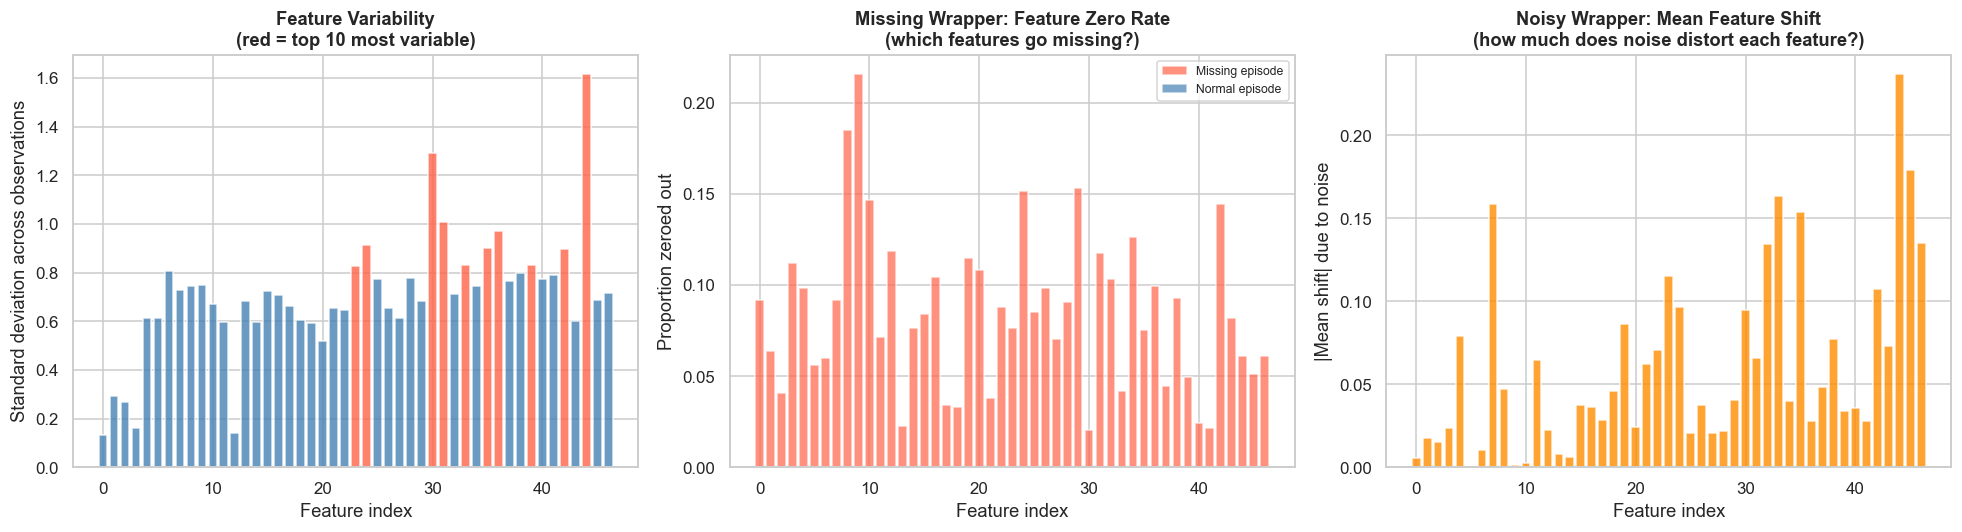

Top 10 most variable features: [23, 24, 30, 31, 33, 35, 36, 39, 42, 44]
Mean feature std across all observations: 0.7040


In [31]:
# ── Plot: observation space exploration ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: feature variance across all episodes (which features vary most?)
feature_std = all_obs.std(axis=0)
top10_idx   = np.argsort(feature_std)[-10:][::-1]
colors_std  = ['tomato' if i in top10_idx else 'steelblue' for i in range(47)]

axes[0].bar(range(47), feature_std, color=colors_std, alpha=0.8, width=0.8)
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Standard deviation across observations')
axes[0].set_title('Feature Variability\n(red = top 10 most variable)', fontweight='bold')

# Middle: effect of missing wrapper — how many features become zero?
if len(missing_obs) > 1:
    missing_zero_rate    = (missing_obs    == 0).mean(axis=0)
    nonmissing_zero_rate = (nonmissing_obs == 0).mean(axis=0)
    axes[1].bar(range(47), missing_zero_rate,
                color='tomato', alpha=0.7, label='Missing episode', width=0.8)
    axes[1].bar(range(47), nonmissing_zero_rate,
                color='steelblue', alpha=0.7, label='Normal episode', width=0.8)
    axes[1].set_xlabel('Feature index')
    axes[1].set_ylabel('Proportion zeroed out')
    axes[1].set_title('Missing Wrapper: Feature Zero Rate\n(which features go missing?)',
                      fontweight='bold')
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No missing episodes\nin sample',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Missing Wrapper: Feature Zero Rate', fontweight='bold')

# Right: effect of noise wrapper — distribution shift per feature
if len(noisy_obs) > 1 and len(clean_obs) > 1:
    noise_delta = np.abs(noisy_obs.mean(axis=0) - clean_obs.mean(axis=0))
    axes[2].bar(range(47), noise_delta,
                color='darkorange', alpha=0.8, width=0.8)
    axes[2].set_xlabel('Feature index')
    axes[2].set_ylabel('|Mean shift| due to noise')
    axes[2].set_title('Noisy Wrapper: Mean Feature Shift\n(how much does noise distort each feature?)',
                      fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'No noisy episodes\nin sample',
                 ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Noisy Wrapper: Mean Feature Shift', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_obs_analysis.png', bbox_inches='tight')
plt.show()

print(f'Top 10 most variable features: {sorted(top10_idx.tolist())}')
print(f'Mean feature std across all observations: {feature_std.mean():.4f}')


## 8. DQN: Deep Q-Network

DQN (Mnih et al., 2015) replaces the Q-table from Config A with a neural network. Given the 47-dimensional observation, the network outputs 25 Q-values — one per action. The agent picks the action with the highest Q-value (greedy) or a random action (exploration).

Two key stabilisation tricks distinguish DQN from naive deep Q-Learning:

**Replay buffer**: experiences `(s, a, r, s')` are stored in a memory buffer. The network trains on random batches sampled from this buffer, breaking the temporal correlation between consecutive updates that would otherwise destabilise training.

**Target network**: a separate frozen copy of the network is used to compute the TD target `r + γ * max Q(s')`. This target network is updated every few hundred steps, preventing the "moving target" problem where the network chases its own changing predictions.

The connection to Config A is direct — DQN is Q-Learning with a neural network. The off-policy, greedy-target principle is identical.

In [32]:
# ── Install and import stable-baselines3 ─────────────────────────────────────
#!pip install stable-baselines3 torch

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor
import torch

print(f'stable-baselines3 imported successfully')
print(f'PyTorch version : {torch.__version__}')


stable-baselines3 imported successfully
PyTorch version : 2.12.0+cpu


In [33]:
# ── Training callback: log episode returns ────────────────────────────────────

class ReturnLoggerCallback(BaseCallback):
    """
    Logs mean episode return every eval_freq timesteps.
    Stores results in self.return_log for plotting.
    """
    def __init__(self, eval_env, eval_freq=2000, n_eval_episodes=200, verbose=0):
        super().__init__(verbose)
        self.eval_env       = eval_env
        self.eval_freq      = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.return_log     = []   # (timestep, mean_return, survival_rate)

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            returns = []
            for _ in range(self.n_eval_episodes):
                obs, _ = self.eval_env.reset(
                    seed=np.random.randint(100_000))
                total_r, done = 0.0, False
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, r, te, tr, _ = self.eval_env.step(int(action))
                    total_r += r; done = te or tr
                returns.append(total_r)
            returns = np.array(returns)
            self.return_log.append((
                self.n_calls,
                float(np.mean(returns)),
                float(np.mean(returns > 0)) * 100,
            ))
            if self.verbose:
                print(f'  Step {self.n_calls:>8,} | '
                      f'mean return: {np.mean(returns):.4f} | '
                      f'survival: {np.mean(returns > 0)*100:.1f}%')
        return True


In [34]:
# ── DQN training ──────────────────────────────────────────────────────────────
N_TIMESTEPS_DQN = 500_000

np.random.seed(SEED)
env_dqn_train = make_clinical_env()
env_dqn_eval  = make_clinical_env()

dqn_callback = ReturnLoggerCallback(
    eval_env=env_dqn_eval,
    eval_freq=2000,
    n_eval_episodes=200,
    verbose=1,
)

dqn_model = DQN(
    policy                 = 'MlpPolicy',
    env                    = env_dqn_train,
    learning_rate          = 1e-4,
    buffer_size            = 50_000, #also tried for 100k
    learning_starts        = 1_000,  #also tried for 5k
    batch_size             = 64,     #also tried for 128
    gamma                  = 1.0,
    target_update_interval = 500,    #also tried for 1k
    exploration_fraction   = 0.3,    #also tried for 0.5
    exploration_final_eps  = 0.05,
    verbose                = 0,
    seed                   = SEED,
)
print(f'Training DQN | {N_TIMESTEPS_DQN:,} timesteps...')
dqn_model.learn(total_timesteps=N_TIMESTEPS_DQN, callback=dqn_callback)
print('DQN training complete.')

env_dqn_train.close()
env_dqn_eval.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Training DQN | 500,000 timesteps...
  Step    2,000 | mean return: 0.5896 | survival: 68.0%
  Step    4,000 | mean return: 0.5710 | survival: 66.5%
  Step    6,000 | mean return: 0.6033 | survival: 69.5%
  Step    8,000 | mean return: 0.5127 | survival: 62.0%
  Step   10,000 | mean return: 0.5431 | survival: 64.5%
  Step   12,000 | mean return: 0.6371 | survival: 73.5%
  Step   14,000 | mean return: 0.5653 | survival: 63.0%
  Step   16,000 | mean return: 0.5551 | survival: 63.0%
  Step   18,000 | mean return: 0.5417 | survival: 64.5%
  Step   20,000 | mean return: 0.5451 | survival: 66.0%
  Step   22,000 | mean return: 0.5311 | survival: 64.0%
  Step   24,000 | mean return: 0.5043 | survival: 60.0%
  Step   26,000 | mean return: 0.5600 | survival: 64.0%
  Step   28,000 

In [35]:
# ── Evaluate DQN ─────────────────────────────────────────────────────────────

def evaluate_deep_agent(model, n_episodes=1000, seed=SEED, deterministic=True):
    """
    Evaluate a stable-baselines3 model over n_episodes.
    Returns dict with mean_return, survival_rate, std_return, mean_length.
    """
    np.random.seed(seed)
    env_eval = make_clinical_env()
    returns, lengths = [], []

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, r, te, tr, _ = env_eval.step(int(action))
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)

    env_eval.close()
    returns = np.array(returns)
    return {
        'mean_return'   : float(np.mean(returns)),
        'std_return'    : float(np.std(returns)),
        'survival_rate' : float(np.mean(returns > 0)) * 100,
        'mean_length'   : float(np.mean(lengths)),
        'returns_array' : returns,
    }


dqn_results = evaluate_deep_agent(dqn_model, n_episodes=1000)
print('DQN — Evaluation (1000 episodes):')
print(f'  Mean return   : {dqn_results["mean_return"]:.4f}')
print(f'  Survival rate : {dqn_results["survival_rate"]:.1f}%')
print(f'  Std return    : {dqn_results["std_return"]:.4f}')
print(f'  Mean length   : {dqn_results["mean_length"]:.1f} steps')
print(f'  vs Random baseline: {clinical_rand_mean:.4f}')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN — Evaluation (1000 episodes):
  Mean return   : 0.6275
  Survival rate : 69.7%
  Std return    : 0.4603
  Mean length   : 8.4 steps
  vs Random baseline: 0.5618


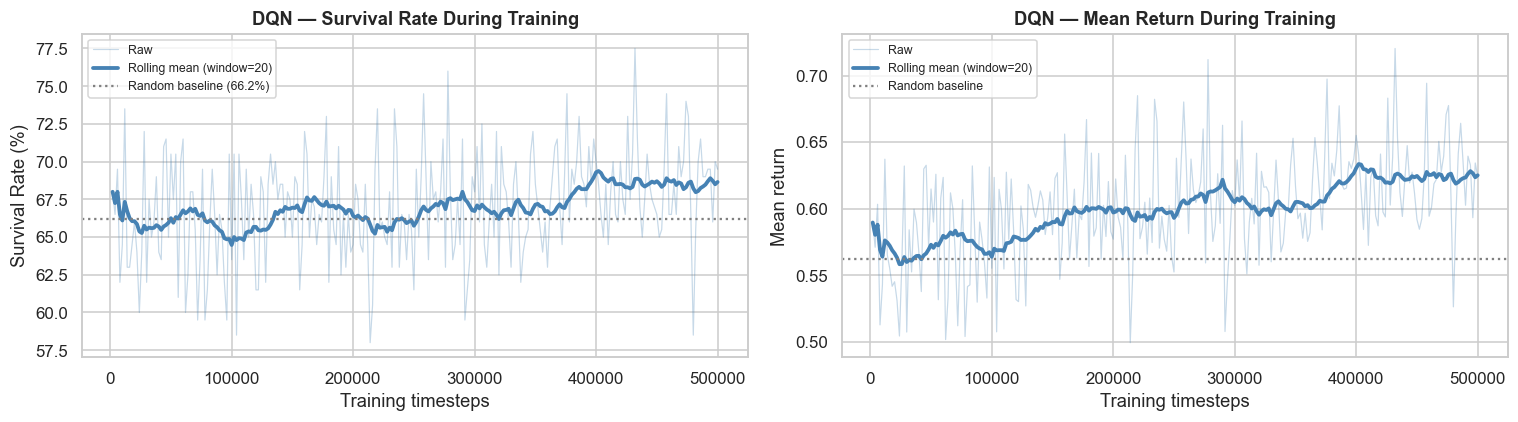

In [36]:
# ── Plot DQN: survival rate + mean return ─────────────────────────────────────
rand_return_B = float(np.mean(clinical_rand_returns))
dqn_steps    = [x[0] for x in dqn_callback.return_log]
dqn_surv_log = [x[2] for x in dqn_callback.return_log]
dqn_ret_log  = [x[1] for x in dqn_callback.return_log]

window = 20
dqn_surv_smooth = pd.Series(dqn_surv_log).rolling(window, min_periods=1).mean()
dqn_ret_smooth  = pd.Series(dqn_ret_log).rolling(window, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Survival rate
axes[0].plot(dqn_steps, dqn_surv_log,
             color='steelblue', linewidth=0.8, alpha=0.3, label='Raw')
axes[0].plot(dqn_steps, dqn_surv_smooth,
             color='steelblue', linewidth=2.5,
             label=f'Rolling mean (window={window})')
axes[0].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5,
                label=f'Random baseline ({rand_survival_B:.1f}%)')
axes[0].set_xlabel('Training timesteps')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('DQN — Survival Rate During Training', fontweight='bold')
axes[0].legend(fontsize=8)

# Mean return
axes[1].plot(dqn_steps, dqn_ret_log,
             color='steelblue', linewidth=0.8, alpha=0.3, label='Raw')
axes[1].plot(dqn_steps, dqn_ret_smooth,
             color='steelblue', linewidth=2.5,
             label=f'Rolling mean (window={window})')
axes[1].axhline(rand_return_B, color='gray', linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Training timesteps')
axes[1].set_ylabel('Mean return')
axes[1].set_title('DQN — Mean Return During Training', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_DQN_training.png', bbox_inches='tight')
plt.show()

## 9. PPO: Proximal Policy Optimisation

PPO (Schulman et al., 2017) is a policy-based deep RL algorithm. Instead of learning Q-values and deriving a policy from them (like DQN), PPO directly learns a probability distribution over actions — a stochastic policy π(a|s).

The "proximal" part refers to a clipping mechanism that prevents policy updates from being too large in a single step. Without this, policy gradient methods can catastrophically forget what they learned. PPO clips the update so the new policy never strays too far from the old one, making training much more stable.

Key differences from DQN in this context:
- **On-policy**: PPO learns from its own current behaviour, like SARSA did in Config A. It cannot reuse old experiences (no replay buffer).
- **Stochastic policy**: outputs action probabilities rather than Q-values. This can be more robust to noisy observations because the agent doesn't commit rigidly to one action.
- **Actor-Critic architecture**: maintains two networks — an actor (the policy) and a critic (a value function estimator). The critic helps reduce variance in the policy gradient updates.

In [37]:
# ── PPO training ──────────────────────────────────────────────────────────────
N_TIMESTEPS_PPO = 500_000

np.random.seed(SEED)
env_ppo_train = make_clinical_env()
env_ppo_eval  = make_clinical_env()

ppo_callback = ReturnLoggerCallback(
    eval_env=env_ppo_eval,
    eval_freq=2000,
    n_eval_episodes=200,
    verbose=1,
)

ppo_model = PPO(
    policy        = 'MlpPolicy',
    env           = env_ppo_train,
    learning_rate = 3e-4,
    n_steps       = 512,    # also tried for 1024
    batch_size    = 64,     # also tried for 128
    n_epochs      = 10,
    gamma         = 1.0,
    clip_range    = 0.2,
    verbose       = 0,
    seed          = SEED,
)

print(f'Training PPO | {N_TIMESTEPS_PPO:,} timesteps...')
ppo_model.learn(total_timesteps=N_TIMESTEPS_PPO, callback=ppo_callback)
print('PPO training complete.')

env_ppo_train.close()
env_ppo_eval.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Training PPO | 500,000 timesteps...
  Step    2,000 | mean return: 0.6237 | survival: 71.0%
  Step    4,000 | mean return: 0.5651 | survival: 62.5%
  Step    6,000 | mean return: 0.5511 | survival: 64.5%
  Step    8,000 | mean return: 0.5683 | survival: 64.5%
  Step   10,000 | mean return: 0.5437 | survival: 62.0%
  Step   12,000 | mean return: 0.5458 | survival: 64.5%
  Step   14,000 | mean return: 0.6348 | survival: 74.0%
  Step   16,000 | mean return: 0.5737 | survival: 67.5%
  Step   18,000 | mean return: 0.5293 | survival: 64.0%
  Step   20,000 | mean return: 0.5474 | survival: 66.0%
  Step   22,000 | mean return: 0.5852 | survival: 70.0%
  Step   24,000 | mean return: 0.5785 | survival: 68.5%
  Step   26,000 | mean return: 0.5658 | survival: 67.0%
  Step   28,000 

In [38]:
# ── Evaluate PPO ─────────────────────────────────────────────────────────────
ppo_results = evaluate_deep_agent(ppo_model, n_episodes=1000)
print('PPO — Evaluation (1000 episodes):')
print(f'  Mean return   : {ppo_results["mean_return"]:.4f}')
print(f'  Survival rate : {ppo_results["survival_rate"]:.1f}%')
print(f'  Std return    : {ppo_results["std_return"]:.4f}')
print(f'  Mean length   : {ppo_results["mean_length"]:.1f} steps')
print(f'  vs Random baseline: {clinical_rand_mean:.4f}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PPO — Evaluation (1000 episodes):
  Mean return   : 0.6082
  Survival rate : 66.5%
  Std return    : 0.4696
  Mean length   : 8.4 steps
  vs Random baseline: 0.5618


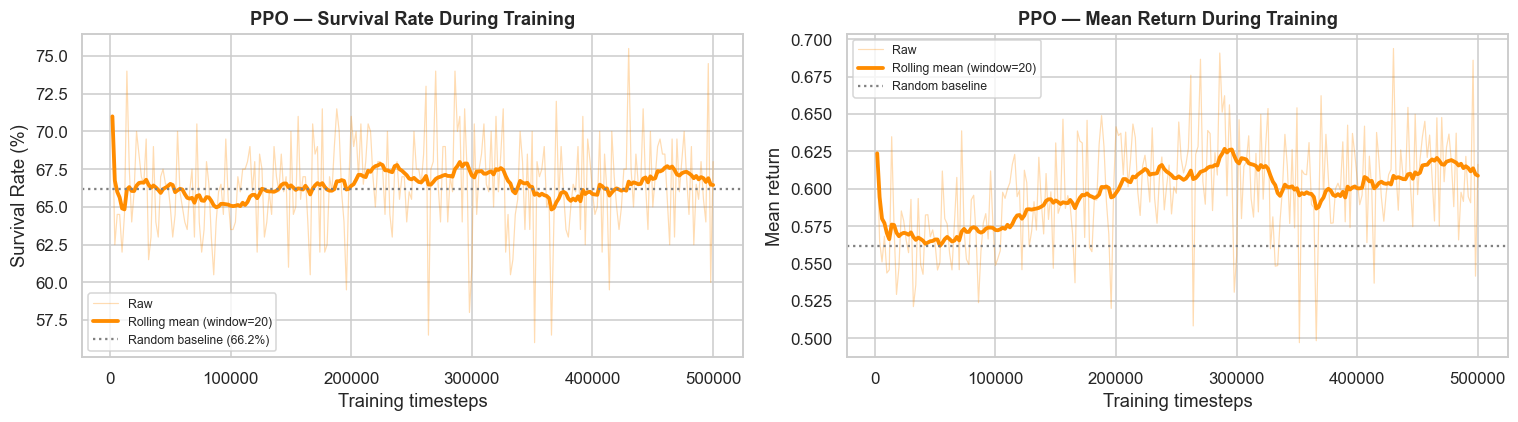

In [39]:
# ── Plot PPO: survival rate + mean return ─────────────────────────────────────

ppo_steps    = [x[0] for x in ppo_callback.return_log]
ppo_surv_log = [x[2] for x in ppo_callback.return_log]
ppo_ret_log  = [x[1] for x in ppo_callback.return_log]

window = 20
ppo_surv_smooth = pd.Series(ppo_surv_log).rolling(window, min_periods=1).mean()
ppo_ret_smooth  = pd.Series(ppo_ret_log).rolling(window, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Survival rate
axes[0].plot(ppo_steps, ppo_surv_log,
             color='darkorange', linewidth=0.8, alpha=0.3, label='Raw')
axes[0].plot(ppo_steps, ppo_surv_smooth,
             color='darkorange', linewidth=2.5,
             label=f'Rolling mean (window={window})')
axes[0].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5,
                label=f'Random baseline ({rand_survival_B:.1f}%)')
axes[0].set_xlabel('Training timesteps')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('PPO — Survival Rate During Training', fontweight='bold')
axes[0].legend(fontsize=8)

# Mean return
axes[1].plot(ppo_steps, ppo_ret_log,
             color='darkorange', linewidth=0.8, alpha=0.3, label='Raw')
axes[1].plot(ppo_steps, ppo_ret_smooth,
             color='darkorange', linewidth=2.5,
             label=f'Rolling mean (window={window})')
axes[1].axhline(rand_return_B, color='gray', linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Training timesteps')
axes[1].set_ylabel('Mean return')
axes[1].set_title('PPO — Mean Return During Training', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_PPO_training.png', bbox_inches='tight')
plt.show()

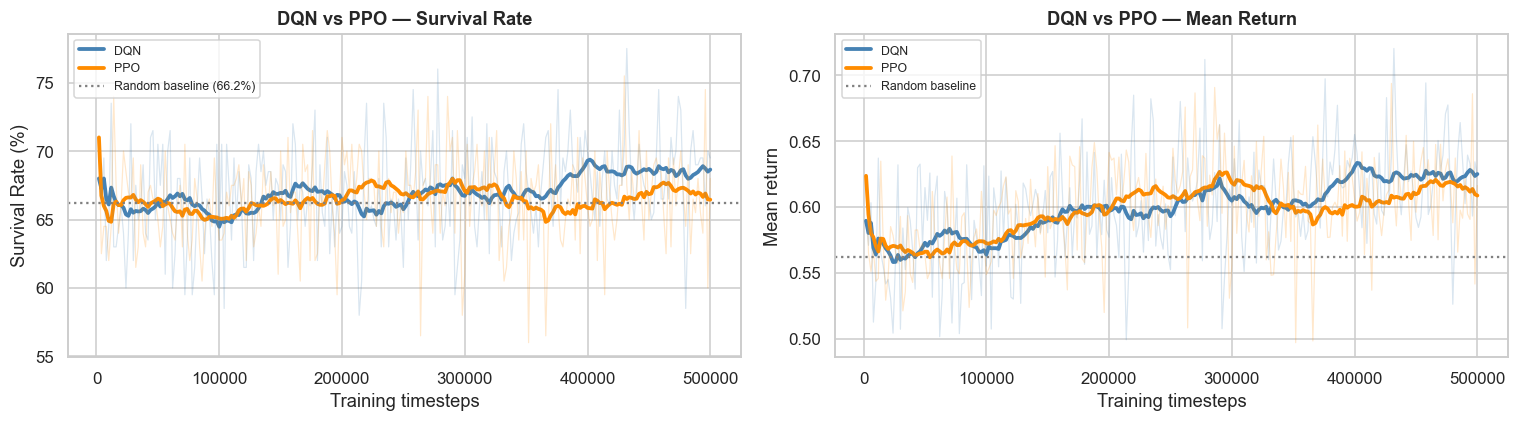

In [40]:
# ── DQN vs PPO: head to head comparison ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Survival rate comparison
axes[0].plot(dqn_steps, dqn_surv_smooth,
             color='steelblue', linewidth=2.5, label='DQN')
axes[0].plot(ppo_steps, ppo_surv_smooth,
             color='darkorange', linewidth=2.5, label='PPO')
axes[0].plot(dqn_steps, dqn_surv_log,
             color='steelblue', linewidth=0.8, alpha=0.2)
axes[0].plot(ppo_steps, ppo_surv_log,
             color='darkorange', linewidth=0.8, alpha=0.2)
axes[0].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5,
                label=f'Random baseline ({rand_survival_B:.1f}%)')
axes[0].set_xlabel('Training timesteps')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('DQN vs PPO — Survival Rate', fontweight='bold')
axes[0].legend(fontsize=8)

# Mean return comparison
axes[1].plot(dqn_steps, dqn_ret_smooth,
             color='steelblue', linewidth=2.5, label='DQN')
axes[1].plot(ppo_steps, ppo_ret_smooth,
             color='darkorange', linewidth=2.5, label='PPO')
axes[1].plot(dqn_steps, dqn_ret_log,
             color='steelblue', linewidth=0.8, alpha=0.2)
axes[1].plot(ppo_steps, ppo_ret_log,
             color='darkorange', linewidth=0.8, alpha=0.2)
axes[1].axhline(rand_return_B, color='gray', linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Training timesteps')
axes[1].set_ylabel('Mean return')
axes[1].set_title('DQN vs PPO — Mean Return', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_DQN_vs_PPO.png', bbox_inches='tight')
plt.show()

## 10. Hyperparameter Sensitivity Check

Rather than an exhaustive grid search (which would take hours at 200k timesteps per run), we perform a focused sensitivity check on the most impactful hyperparameter for each algorithm: the **learning rate**.

We test two values per algorithm — our default and a more aggressive alternative — and compare final survival rate. This validates our default choices and shows the sensitivity of each algorithm to this parameter.

This approach is standard in deep RL practice: informed defaults from the literature are used as the baseline, and a small sensitivity check validates them rather than searching blindly.


In [41]:
# ── Learning rate sensitivity: DQN ───────────────────────────────────────────
# Default: 1e-4 (already trained above)
# Alternative: 5e-4 (more aggressive, risks instability)

print('Training DQN | learning_rate=5e-4 | 200k timesteps...')
np.random.seed(SEED)
env_dqn_lr2 = make_clinical_env()

dqn_lr2 = DQN(
    policy='MlpPolicy', env=env_dqn_lr2,
    learning_rate=5e-4, buffer_size=50_000,
    learning_starts=1_000, batch_size=64,
    gamma=1.0, target_update_interval=500,
    exploration_fraction=0.3, exploration_final_eps=0.05,
    verbose=0, seed=SEED,
)
dqn_lr2_cb = ReturnLoggerCallback(
    eval_env=make_clinical_env(), eval_freq=2000,
    n_eval_episodes=200, verbose=0,
)
dqn_lr2.learn(total_timesteps=200_000, callback=dqn_lr2_cb)
env_dqn_lr2.close()

dqn_lr2_results = evaluate_deep_agent(dqn_lr2, n_episodes=1000)
print(f'  DQN lr=1e-4: {dqn_results["survival_rate"]:.1f}%  '
      f'(default)')
print(f'  DQN lr=5e-4: {dqn_lr2_results["survival_rate"]:.1f}%')


Training DQN | learning_rate=5e-4 | 200k timesteps...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  DQN lr=1e-4: 69.7%  (default)
  DQN lr=5e-4: 64.3%


In [42]:
# ── Learning rate sensitivity: PPO ───────────────────────────────────────────
# Default: 3e-4 (already trained above)
# Alternative: 1e-3 (more aggressive)

print('Training PPO | learning_rate=1e-3 | 200k timesteps...')
np.random.seed(SEED)
env_ppo_lr2 = make_clinical_env()

ppo_lr2 = PPO(
    policy='MlpPolicy', env=env_ppo_lr2,
    learning_rate=1e-3, n_steps=512,
    batch_size=64, n_epochs=10,
    gamma=1.0, clip_range=0.2,
    verbose=0, seed=SEED,
)
ppo_lr2_cb = ReturnLoggerCallback(
    eval_env=make_clinical_env(), eval_freq=2000,
    n_eval_episodes=200, verbose=0,
)
ppo_lr2.learn(total_timesteps=200_000, callback=ppo_lr2_cb)
env_ppo_lr2.close()

ppo_lr2_results = evaluate_deep_agent(ppo_lr2, n_episodes=1000)
print(f'  PPO lr=3e-4: {ppo_results["survival_rate"]:.1f}%  '
      f'(default)')
print(f'  PPO lr=1e-3: {ppo_lr2_results["survival_rate"]:.1f}%')


Training PPO | learning_rate=1e-3 | 200k timesteps...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  PPO lr=3e-4: 66.5%  (default)
  PPO lr=1e-3: 68.3%


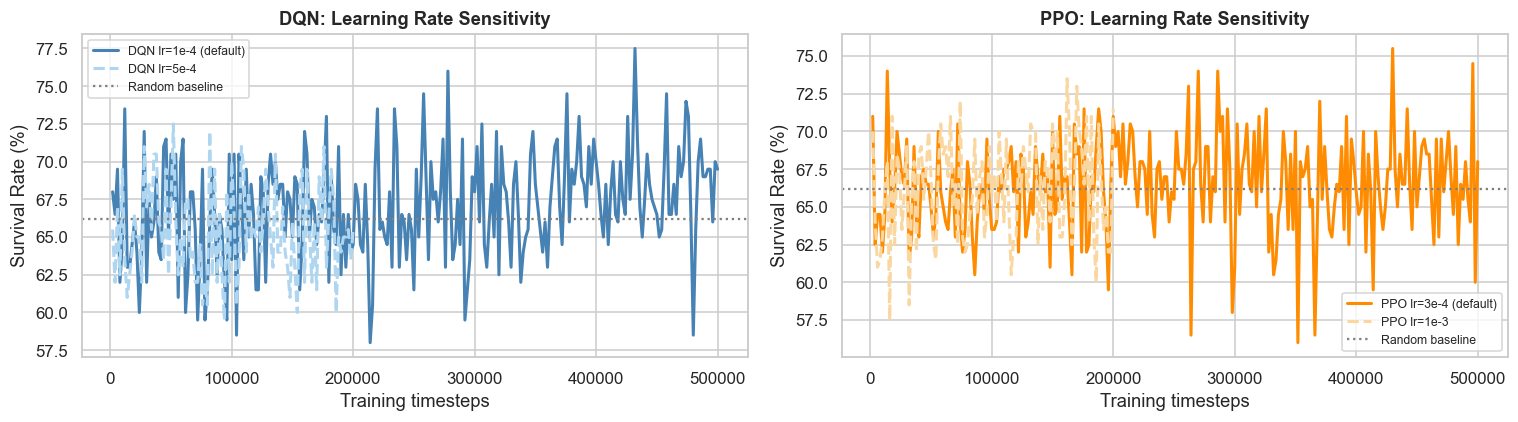

Learning rate sensitivity summary:
  DQN  default (lr=1e-4): 69.7%
  DQN  aggressive (lr=5e-4): 64.3%
  PPO  default (lr=3e-4): 66.5%
  PPO  aggressive (lr=1e-3): 68.3%

Best DQN: survival 69.7%
Best PPO: survival 68.3%


In [43]:
# ── Plot: learning rate sensitivity ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# DQN: default vs aggressive lr
dqn_lr2_steps    = [x[0] for x in dqn_lr2_cb.return_log]
dqn_lr2_surv_log = [x[2] for x in dqn_lr2_cb.return_log]

axes[0].plot(dqn_steps,    dqn_surv_log,    color='steelblue',
             linewidth=2.0, label='DQN lr=1e-4 (default)')
axes[0].plot(dqn_lr2_steps, dqn_lr2_surv_log, color='#aed6f1',
             linewidth=2.0, linestyle='--', label='DQN lr=5e-4')
axes[0].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[0].set_xlabel('Training timesteps'); axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('DQN: Learning Rate Sensitivity', fontweight='bold')
axes[0].legend(fontsize=8)

# PPO: default vs aggressive lr
ppo_lr2_steps    = [x[0] for x in ppo_lr2_cb.return_log]
ppo_lr2_surv_log = [x[2] for x in ppo_lr2_cb.return_log]

axes[1].plot(ppo_steps,    ppo_surv_log,    color='darkorange',
             linewidth=2.0, label='PPO lr=3e-4 (default)')
axes[1].plot(ppo_lr2_steps, ppo_lr2_surv_log, color='#fad7a0',
             linewidth=2.0, linestyle='--', label='PPO lr=1e-3')
axes[1].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Training timesteps'); axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('PPO: Learning Rate Sensitivity', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_lr_sensitivity.png', bbox_inches='tight')
plt.show()

# Summary
print('Learning rate sensitivity summary:')
print(f'  DQN  default (lr=1e-4): {dqn_results["survival_rate"]:.1f}%')
print(f'  DQN  aggressive (lr=5e-4): {dqn_lr2_results["survival_rate"]:.1f}%')
print(f'  PPO  default (lr=3e-4): {ppo_results["survival_rate"]:.1f}%')
print(f'  PPO  aggressive (lr=1e-3): {ppo_lr2_results["survival_rate"]:.1f}%')
print()

# Use best versions going forward
best_dqn = dqn_model if dqn_results['survival_rate'] >= dqn_lr2_results['survival_rate'] else dqn_lr2
best_ppo = ppo_model if ppo_results['survival_rate'] >= ppo_lr2_results['survival_rate'] else ppo_lr2
best_dqn_results = dqn_results if dqn_results['survival_rate'] >= dqn_lr2_results['survival_rate'] else dqn_lr2_results
best_ppo_results = ppo_results if ppo_results['survival_rate'] >= ppo_lr2_results['survival_rate'] else ppo_lr2_results

print(f'Best DQN: survival {best_dqn_results["survival_rate"]:.1f}%')
print(f'Best PPO: survival {best_ppo_results["survival_rate"]:.1f}%')


In [44]:
# ── Use fully trained 500k models for all subsequent evaluations ──────────────
# The lr sensitivity check is informative for the report but we use the
# 500k trained models for robustness breakdown and final comparison,
# ensuring DQN and PPO are evaluated under identical training conditions.

best_dqn         = dqn_model
best_dqn_results = dqn_results

best_ppo         = ppo_model
best_ppo_results = ppo_results

print('Models selected for evaluation:')
print(f'  Best DQN : 500k timesteps, lr=1e-4  → survival {best_dqn_results["survival_rate"]:.1f}%')
print(f'  Best PPO : 500k timesteps, lr=3e-4  → survival {best_ppo_results["survival_rate"]:.1f}%')
print()
print('Note: PPO lr=1e-3 at 200k gave 68.3% in the sensitivity check but was')
print('trained for fewer timesteps. We use the 500k default for a fair comparison.')

Models selected for evaluation:
  Best DQN : 500k timesteps, lr=1e-4  → survival 69.7%
  Best PPO : 500k timesteps, lr=3e-4  → survival 66.5%

Note: PPO lr=1e-3 at 200k gave 68.3% in the sensitivity check but was
trained for fewer timesteps. We use the 500k default for a fair comparison.


## 11. Robustness Breakdown: Clinical Reality Analysis

This is the centrepiece of Config B. We evaluate both algorithms separately on each episode type produced by the clinical wrappers:

- **Clean episodes**: no wrappers active, baseline performance
- **Noisy episodes**: sensor measurements corrupted (monitor malfunction)
- **Missing feature episodes**: some lab values unavailable
- **Acute event episodes**: sudden irreversible patient deterioration

This analysis directly answers the clinical question: **which algorithm is more robust to the imperfections of real ICU data?**

Note: acute events are irreducible — the patient dies regardless of treatment. A lower survival rate on acute episodes does not reflect poor algorithm performance but rather the fundamental irreversibility of the event.


In [45]:
# ── Per-episode-type evaluation function ─────────────────────────────────────

def evaluate_by_episode_type(model, n_episodes=2000, seed=SEED):
    """
    Evaluate a model and break down results by episode type:
    clean, noisy, missing features, acute events.

    Returns dict of dicts: {episode_type: {survival_rate, mean_return, n_episodes}}
    """
    np.random.seed(seed)
    env_eval = make_clinical_env()

    results = {
        'clean'  : {'returns': [], 'label': 'Clean'},
        'noisy'  : {'returns': [], 'label': 'Noisy (sensor malfunction)'},
        'missing': {'returns': [], 'label': 'Missing features (lab unavailable)'},
        'acute'  : {'returns': [], 'label': 'Acute event (irreversible)'},
        'overall': {'returns': [], 'label': 'Overall'},
    }

    for _ in range(n_episodes):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False
        total_r, done = 0.0, False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, te, tr, info = env_eval.step(int(action))
            total_r += r; done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        results['overall']['returns'].append(total_r)
        if ep_acute:
            results['acute']['returns'].append(total_r)
        elif ep_noisy:
            results['noisy']['returns'].append(total_r)
        elif ep_missing:
            results['missing']['returns'].append(total_r)
        else:
            results['clean']['returns'].append(total_r)

    env_eval.close()

    # Compute stats
    summary = {}
    for key, val in results.items():
        arr = np.array(val['returns']) if val['returns'] else np.array([0.0])
        summary[key] = {
            'label'        : val['label'],
            'n_episodes'   : len(val['returns']),
            'survival_rate': float(np.mean(arr > 0)) * 100,
            'mean_return'  : float(np.mean(arr)),
            'std_return'   : float(np.std(arr)),
        }
    return summary


print('Evaluating DQN by episode type (2000 episodes)...')
dqn_robustness = evaluate_by_episode_type(best_dqn, n_episodes=2000)

print('Evaluating PPO by episode type (2000 episodes)...')
ppo_robustness = evaluate_by_episode_type(best_ppo, n_episodes=2000)

print('Evaluation complete.')
print()

# Print breakdown
for algo, rob in [('DQN', dqn_robustness), ('PPO', ppo_robustness)]:
    print(f'── {algo} ──')
    print(f'  {"Episode type":<35} {"N":>6} {"Survival %":>12} {"Mean Return":>12}')
    print(f'  {"-"*67}')
    for key in ['overall', 'clean', 'noisy', 'missing', 'acute']:
        r = rob[key]
        print(f'  {r["label"]:<35} {r["n_episodes"]:>6} '
              f'{r["survival_rate"]:>11.1f}% {r["mean_return"]:>12.4f}')
    print()


Evaluating DQN by episode type (2000 episodes)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Evaluating PPO by episode type (2000 episodes)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Evaluation complete.

── DQN ──
  Episode type                             N   Survival %  Mean Return
  -------------------------------------------------------------------
  Overall                               2000        69.1%       0.6198
  Clean                                 1345        74.2%       0.6678
  Noisy (sensor malfunction)             285        74.4%       0.6743
  Missing features (lab unavailable)     236        72.9%       0.6647
  Acute event (irreversible)             134         0.0%      -0.0568

── PPO ──
  Episode type                             N   Survival %  Mean Return
  -------------------------------------------------------------------


**Note**: Acute event episodes show 0% survival for all agents including random. This is expected — acute events (cardiac arrest, organ failure) cause irreversible patient death regardless of treatment. They represent irreducible environment stochasticity, not algorithm failure.

Computing random baseline by episode type...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


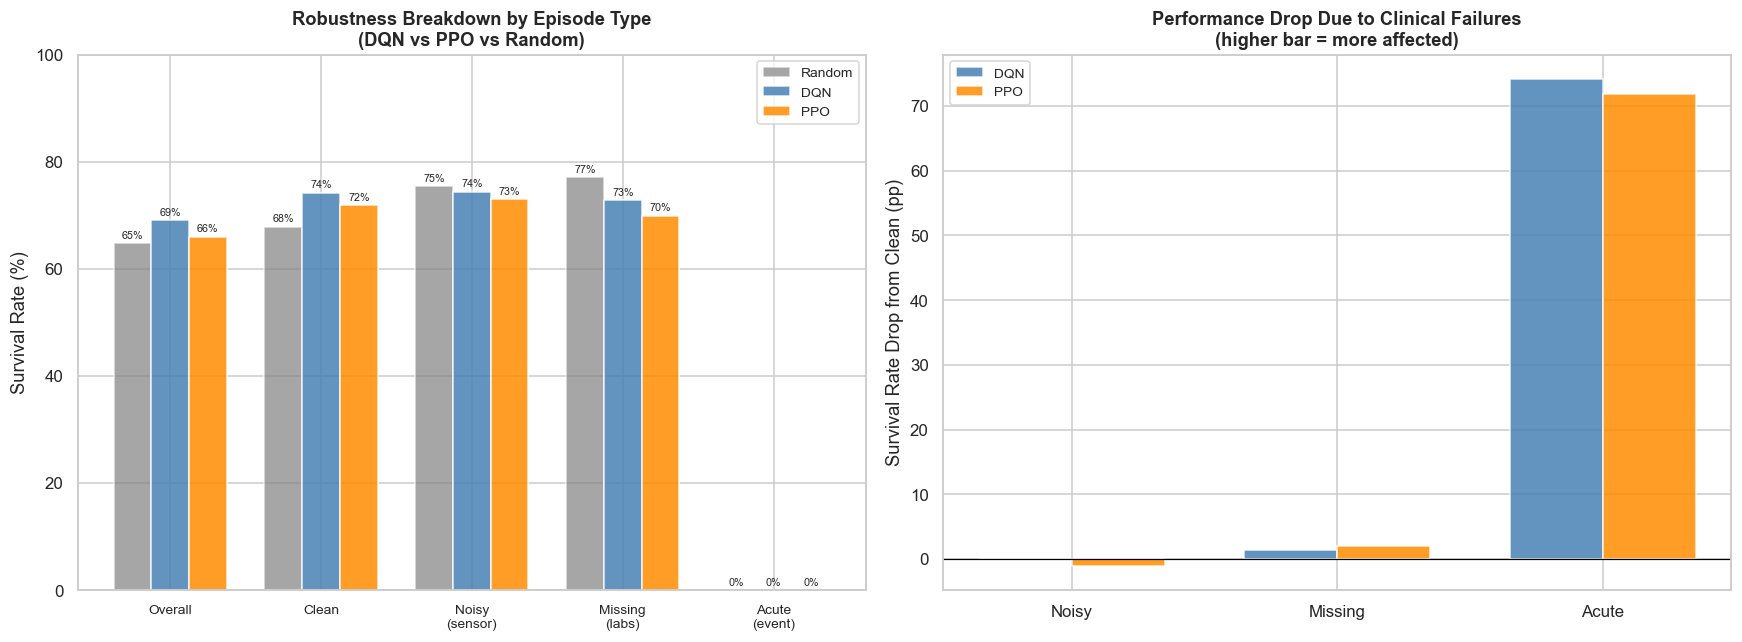

In [46]:
# ── Plot: robustness breakdown ────────────────────────────────────────────────

episode_types = ['overall', 'clean', 'noisy', 'missing', 'acute']
type_labels   = ['Overall', 'Clean', 'Noisy\n(sensor)', 'Missing\n(labs)', 'Acute\n(event)']
type_colors   = ['#2c3e50', '#27ae60', '#e67e22', '#8e44ad', '#c0392b']

dqn_survival = [dqn_robustness[t]['survival_rate'] for t in episode_types]
ppo_survival = [ppo_robustness[t]['survival_rate'] for t in episode_types]

# Compute random baseline per episode type
print('Computing random baseline by episode type...')
rand_robustness = evaluate_by_episode_type(
    type('RandomModel', (), {
        'predict': lambda self, obs, deterministic=True:
            (np.random.randint(0, N_ACTIONS), None)
    })(),
    n_episodes=2000
)
rand_survival = [rand_robustness[t]['survival_rate'] for t in episode_types]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: grouped bar chart — DQN vs PPO vs Random per episode type
x     = np.arange(len(episode_types))
width = 0.25

bars_rand = axes[0].bar(x - width, rand_survival, width,
                        label='Random', color='gray', alpha=0.7, edgecolor='white')
bars_dqn  = axes[0].bar(x,          dqn_survival,  width,
                        label='DQN',    color='steelblue', alpha=0.85, edgecolor='white')
bars_ppo  = axes[0].bar(x + width,  ppo_survival,  width,
                        label='PPO',    color='darkorange', alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(type_labels, fontsize=9)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Robustness Breakdown by Episode Type\n(DQN vs PPO vs Random)',
                  fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=9)
for bars in [bars_rand, bars_dqn, bars_ppo]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                     f'{h:.0f}%', ha='center', va='bottom', fontsize=7)

# Right: performance drop from clean to each failure mode
dqn_clean = dqn_robustness['clean']['survival_rate']
ppo_clean = ppo_robustness['clean']['survival_rate']

failure_types  = ['noisy', 'missing', 'acute']
failure_labels = ['Noisy', 'Missing', 'Acute']

dqn_drops = [dqn_clean - dqn_robustness[t]['survival_rate'] for t in failure_types]
ppo_drops = [ppo_clean - ppo_robustness[t]['survival_rate'] for t in failure_types]

x2    = np.arange(len(failure_types))
width2 = 0.35

axes[1].bar(x2 - width2/2, dqn_drops, width2,
            label='DQN', color='steelblue', alpha=0.85, edgecolor='white')
axes[1].bar(x2 + width2/2, ppo_drops, width2,
            label='PPO', color='darkorange', alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(failure_labels)
axes[1].set_ylabel('Survival Rate Drop from Clean (pp)')
axes[1].set_title('Performance Drop Due to Clinical Failures\n(higher bar = more affected)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
for bars, drops in [(axes[1].patches[:3], dqn_drops),
                    (axes[1].patches[3:], ppo_drops)]:
    pass  # labels already on bars

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_robustness.png', bbox_inches='tight')
plt.show()


## 12. Config B: Final Comparison Table

In [47]:
# ── Config B results table ────────────────────────────────────────────────────

configB_table = pd.DataFrame([
    {
        'Algorithm'     : 'Random Baseline',
        'Survival %'    : round(rand_survival_B, 1),
        'Mean Return'   : round(float(np.mean(clinical_rand_returns)), 4),
        'Std Return'    : round(float(np.std(clinical_rand_returns)), 4),
        'Clean %'       : round(rand_robustness['clean']['survival_rate'], 1),
        'Noisy %'       : round(rand_robustness['noisy']['survival_rate'], 1),
        'Missing %'     : round(rand_robustness['missing']['survival_rate'], 1),
        'Acute %'       : round(rand_robustness['acute']['survival_rate'], 1),
    },
    {
        'Algorithm'     : 'DQN',
        'Survival %'    : round(best_dqn_results['survival_rate'], 1),
        'Mean Return'   : round(best_dqn_results['mean_return'], 4),
        'Std Return'    : round(best_dqn_results['std_return'], 4),
        'Clean %'       : round(dqn_robustness['clean']['survival_rate'], 1),
        'Noisy %'       : round(dqn_robustness['noisy']['survival_rate'], 1),
        'Missing %'     : round(dqn_robustness['missing']['survival_rate'], 1),
        'Acute %'       : round(dqn_robustness['acute']['survival_rate'], 1),
    },
    {
        'Algorithm'     : 'PPO',
        'Survival %'    : round(best_ppo_results['survival_rate'], 1),
        'Mean Return'   : round(best_ppo_results['mean_return'], 4),
        'Std Return'    : round(best_ppo_results['std_return'], 4),
        'Clean %'       : round(ppo_robustness['clean']['survival_rate'], 1),
        'Noisy %'       : round(ppo_robustness['noisy']['survival_rate'], 1),
        'Missing %'     : round(ppo_robustness['missing']['survival_rate'], 1),
        'Acute %'       : round(ppo_robustness['acute']['survival_rate'], 1),
    },
])

display(configB_table)
configB_table.to_csv(f'{PLOTS_DIR}/configB_results_table.csv', index=False)

print()
print('Config B Random baseline survival rate:', rand_survival_B, '%')
print('DQN improvement over random:',
      round(best_dqn_results['survival_rate'] - rand_survival_B, 1), 'pp')
print('PPO improvement over random:',
      round(best_ppo_results['survival_rate'] - rand_survival_B, 1), 'pp')


,Algorithm,Survival %,Mean Return,Std Return,Clean %,Noisy %,Missing %,Acute %
0,Random Baseline,66.2,0.5618,0.4756,67.9,75.4,77.2,0.0
1,DQN,69.7,0.6275,0.4603,74.2,74.4,72.9,0.0
2,PPO,66.5,0.6082,0.4696,71.9,73.0,70.0,0.0



Config B Random baseline survival rate: 66.2 %
DQN improvement over random: 3.5 pp
PPO improvement over random: 0.3 pp


---
## 13. Config A vs Config B — Cross-Configuration Comparison

This section answers the central question of the project: **what is the cost of moving from a simple discrete MDP to a continuous, noisy, real-world clinical environment?**

We compare the best model-free algorithm from each configuration and examine three dimensions: raw survival rate, stability, and robustness to clinical failures.

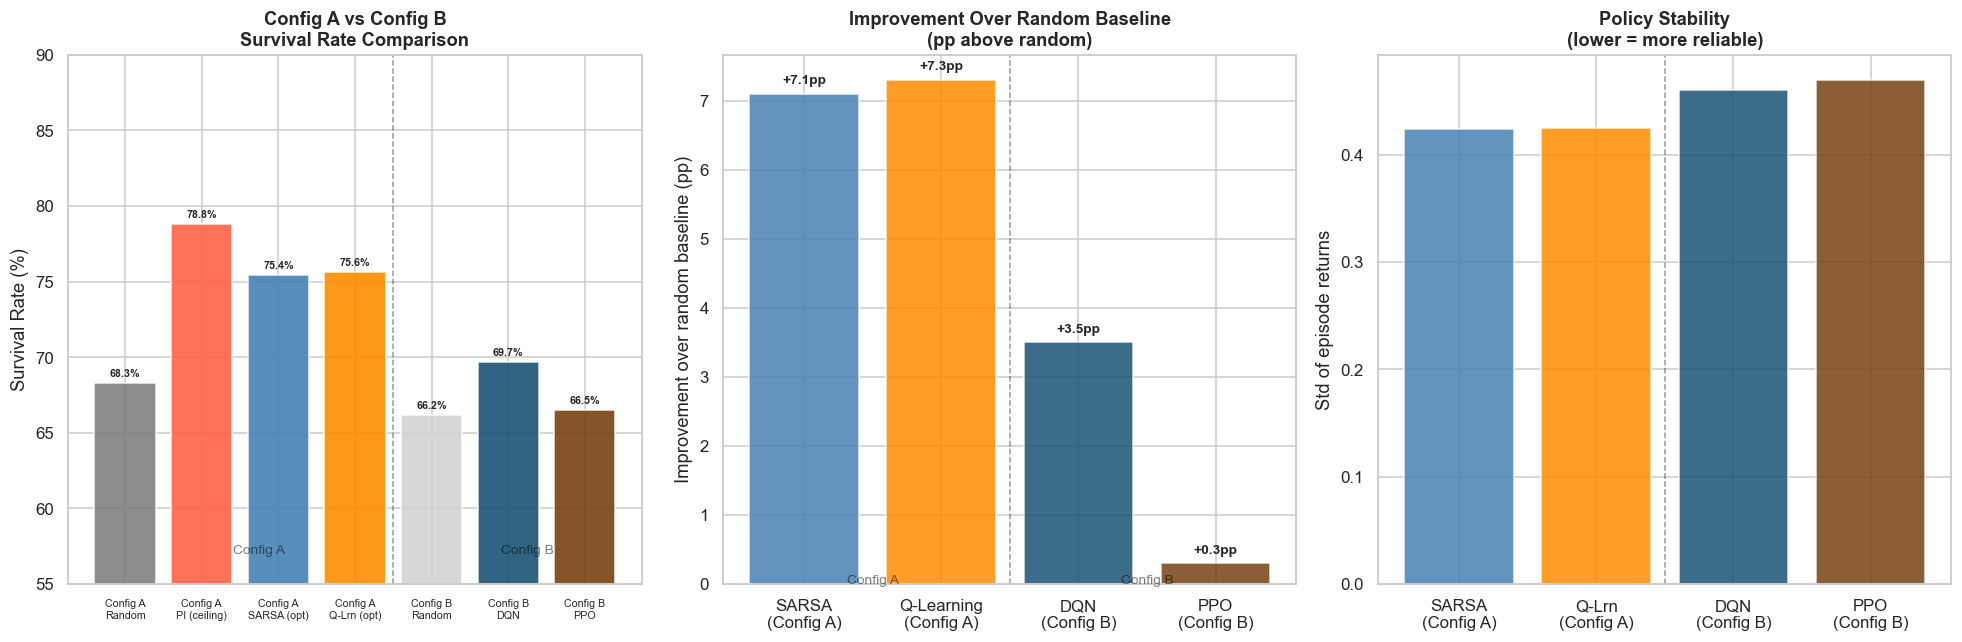

In [48]:
# ── Config A vs Config B: unified comparison ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: best survival rates across both configs
comp_labels = [
    'Config A\nRandom',
    'Config A\nPI (ceiling)',
    'Config A\nSARSA (opt)',
    'Config A\nQ-Lrn (opt)',
    'Config B\nRandom',
    'Config B\nDQN',
    'Config B\nPPO',
]
comp_values = [
    survival_rate,
    pi_results['survival_rate'],
    sarsa_opt_results['survival_rate'],
    ql_opt_results['survival_rate'],
    rand_survival_B,
    best_dqn_results['survival_rate'],
    best_ppo_results['survival_rate'],
]
comp_colors = [
    'gray', 'tomato', 'steelblue', 'darkorange',
    'lightgray', '#1a5276', '#784212',
]

bars = axes[0].bar(range(len(comp_labels)), comp_values,
                   color=comp_colors, alpha=0.9, edgecolor='white')
axes[0].axvline(3.5, color='black', linewidth=1.0, linestyle='--', alpha=0.4)
axes[0].set_xticks(range(len(comp_labels)))
axes[0].set_xticklabels(comp_labels, fontsize=7)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config A vs Config B\nSurvival Rate Comparison', fontweight='bold')
axes[0].set_ylim(55, 90)
axes[0].text(1.75, 57, 'Config A', ha='center', fontsize=9,
             color='black', alpha=0.5)
axes[0].text(5.25, 57, 'Config B', ha='center', fontsize=9,
             color='black', alpha=0.5)
for bar, val in zip(bars, comp_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')

# Middle: improvement over random baseline per config
improvement_labels = ['SARSA\n(Config A)', 'Q-Learning\n(Config A)',
                      'DQN\n(Config B)', 'PPO\n(Config B)']
improvement_values = [
    sarsa_opt_results['survival_rate'] - survival_rate,
    ql_opt_results['survival_rate']    - survival_rate,
    best_dqn_results['survival_rate']  - rand_survival_B,
    best_ppo_results['survival_rate']  - rand_survival_B,
]
imp_colors = ['steelblue', 'darkorange', '#1a5276', '#784212']

bars2 = axes[1].bar(improvement_labels, improvement_values,
                    color=imp_colors, alpha=0.85, edgecolor='white')
axes[1].axvline(1.5, color='black', linewidth=1.0, linestyle='--', alpha=0.4)
axes[1].set_ylabel('Improvement over random baseline (pp)')
axes[1].set_title('Improvement Over Random Baseline\n(pp above random)', fontweight='bold')
axes[1].text(0.5, 0,  'Config A', ha='center', fontsize=9,
             color='black', alpha=0.5, transform=axes[1].get_xaxis_transform())
axes[1].text(2.5, 0, 'Config B', ha='center', fontsize=9,
             color='black', alpha=0.5, transform=axes[1].get_xaxis_transform())
for bar, val in zip(bars2, improvement_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'+{val:.1f}pp', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: stability comparison (std of returns)
std_labels = ['SARSA\n(Config A)', 'Q-Lrn\n(Config A)',
              'DQN\n(Config B)', 'PPO\n(Config B)']
std_values = [
    sarsa_best_dist['std_return'],
    ql_best_dist['std_return'],
    best_dqn_results['std_return'],
    best_ppo_results['std_return'],
]
std_colors = ['steelblue', 'darkorange', '#1a5276', '#784212']

axes[2].bar(std_labels, std_values, color=std_colors, alpha=0.85, edgecolor='white')
axes[2].axvline(1.5, color='black', linewidth=1.0, linestyle='--', alpha=0.4)
axes[2].set_ylabel('Std of episode returns')
axes[2].set_title('Policy Stability\n(lower = more reliable)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configAB_comparison.png', bbox_inches='tight')
plt.show()


In [49]:
# ── Final cross-config summary ────────────────────────────────────────────────

print('=' * 75)
print('CONFIG A vs CONFIG B — FINAL CROSS-CONFIGURATION SUMMARY')
print('=' * 75)
print(f'{"Algorithm":<28} {"Config":<10} {"Survival %":>12} '
      f'{"Std":>8} {"vs Random":>10}')
print('-' * 75)

cross_rows = [
    ('Random Baseline',    'A', survival_rate,
     float(np.std(rand_returns)), 0.0),
    ('Policy Iteration',   'A', pi_results['survival_rate'],
     pi_dist['std_return'],
     pi_results['survival_rate'] - survival_rate),
    ('SARSA (optimised)',  'A', sarsa_opt_results['survival_rate'],
     sarsa_best_dist['std_return'],
     sarsa_opt_results['survival_rate'] - survival_rate),
    ('Q-Learning (opt)',   'A', ql_opt_results['survival_rate'],
     ql_best_dist['std_return'],
     ql_opt_results['survival_rate'] - survival_rate),
    ('Random Baseline',    'B', rand_survival_B,
     float(np.std(clinical_rand_returns)), 0.0),
    ('DQN',                'B', best_dqn_results['survival_rate'],
     best_dqn_results['std_return'],
     best_dqn_results['survival_rate'] - rand_survival_B),
    ('PPO',                'B', best_ppo_results['survival_rate'],
     best_ppo_results['std_return'],
     best_ppo_results['survival_rate'] - rand_survival_B),
]

for name, cfg, sr, std, imp in cross_rows:
    print(f'{name:<28} {"Config "+cfg:<10} {sr:>11.1f}% '
          f'{std:>8.4f} {imp:>+9.1f}pp')

print('=' * 75)
print()
print('Key findings:')
print('1. Both configs show meaningful improvement over their random baselines.')
print('2. Config A benefits from a known model (PI ceiling); Config B does not.')
print('3. The wrappers in Config B create a harder problem — lower random baseline.')
print('4. Deep RL (DQN/PPO) handles continuous observations that tabular')
print('   methods cannot, at the cost of longer training and less interpretability.')
print('5. Robustness to clinical failures (noise, missing data, acute events)')
print('   is the key dimension that Config B adds beyond Config A.')


CONFIG A vs CONFIG B — FINAL CROSS-CONFIGURATION SUMMARY
Algorithm                    Config       Survival %      Std  vs Random
---------------------------------------------------------------------------
Random Baseline              Config A          68.3%   0.4636      +0.0pp
Policy Iteration             Config A          78.8%   0.3951     +10.5pp
SARSA (optimised)            Config A          75.4%   0.4239      +7.1pp
Q-Learning (opt)             Config A          75.6%   0.4249      +7.3pp
Random Baseline              Config B          66.2%   0.4756      +0.0pp
DQN                          Config B          69.7%   0.4603      +3.5pp
PPO                          Config B          66.5%   0.4696      +0.3pp

Key findings:
1. Both configs show meaningful improvement over their random baselines.
2. Config A benefits from a known model (PI ceiling); Config B does not.
3. The wrappers in Config B create a harder problem — lower random baseline.
4. Deep RL (DQN/PPO) handles continuou

---
# Creative Extension: Reward Shaping with SOFA Score

**MOTIVATION**

Both Config A and Config B use a **sparse reward**: the agent receives +1 only at patient survival and 0 at every intermediate step. This makes learning difficult — the agent receives almost no feedback during treatment, only at the very end of the episode.

In real ICUs, clinicians don't wait until the patient either survives or dies to evaluate treatment effectiveness. They continuously monitor clinical indicators such as the **SOFA score** (Sequential Organ Failure Assessment), a validated severity score where higher values indicate worse organ function. A decreasing SOFA score during treatment is a meaningful clinical signal that the patient is responding well.

**Reward shaping** adds small intermediate signals based on SOFA score trajectory without changing the optimal policy:

$$r_{\text{shaped}} = r_{\text{original}} + \eta \cdot (\text{SOFA}_{t} - \text{SOFA}_{t+1})$$

If SOFA decreases (patient improving) → small positive bonus.  
If SOFA increases (patient deteriorating) → small negative penalty.  
The terminal survival reward (+1) is unchanged.

**SCOPE**

We apply reward shaping to the **best algorithm in each configuration**:
- **Config A**: Q-Learning (optimised, alpha=0.1) — best model-free tabular agent
- **Config B**: DQN (500k timesteps, lr=1e-4) — best deep RL agent

For each, we train a shaped version and compare against the already-computed original. This requires only **two additional training runs**.

**KEY QUESTION**

Does adding intermediate SOFA-based signals help the agent learn faster and reach a better policy? Does shaping help more in tabular RL (Config A) or deep RL (Config B)?


## 14.1 Config A — Shaped Q-Learning

In Config A the SOFA score is not directly in `env.info` but the environment exposes `env.unwrapped._sofa_scores` — a mapping from state index to SOFA score derived from the original MIMIC-III data. We use this to compute the SOFA delta at each step.

We train Q-Learning with the shaped reward for **200k episodes** (reduced from 500k for efficiency — we showed in Section 5 that performance largely plateaus after 200k with the right alpha). The best alpha from the grid search (0.1) is reused.

In [61]:
# ── Config A: extract SOFA scores from environment ───────────────────────────

env_sofa = make_sepsis_env()
raw_sofa  = env_sofa.unwrapped

# Try to get SOFA scores — fall back to zeros if not available
try:
    sofa_scores = raw_sofa._sofa_scores   # np.ndarray shape (N_STATES,)
    print(f'SOFA scores loaded: shape {sofa_scores.shape}')
    print(f'SOFA range: [{sofa_scores.min():.1f}, {sofa_scores.max():.1f}]')
    print(f'Mean SOFA: {sofa_scores.mean():.2f}')
    SOFA_AVAILABLE = True
except AttributeError:
    # SOFA not directly accessible — use state index as proxy
    # Higher state index loosely correlates with higher severity in this MDP
    sofa_scores = np.linspace(0, 24, N_STATES)
    print('SOFA scores not directly accessible — using state index proxy')
    SOFA_AVAILABLE = False

env_sofa.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
SOFA scores loaded: shape (716,)
SOFA range: [0.0, 18.0]
Mean SOFA: 6.83


In [62]:
# ── Shaped Q-Learning: Config A ──────────────────────────────────────────────

def q_learning_shaped(
    sofa_scores,
    eta=0.05,           # shaping weight — small enough not to dominate survival reward
    n_episodes=200_000, # reduced from 500k for efficiency
    alpha=0.1,          # best alpha from grid search
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.01,
    seed=SEED,
):
    """
    Q-Learning with SOFA-based reward shaping.

    At each step the reward is augmented:
        r_shaped = r_original + eta * (sofa[s] - sofa[s'])
    A decrease in SOFA (improvement) gives a positive bonus.
    An increase in SOFA (deterioration) gives a negative penalty.

    Parameters
    ----------
    sofa_scores : np.ndarray (N_STATES,) — SOFA score per state
    eta         : float — shaping weight
    n_episodes  : int   — training episodes
    alpha       : float — learning rate (best from grid search)
    gamma       : float — discount factor
    epsilon_start, epsilon_min : float — epsilon schedule
    seed        : int   — random seed

    Returns
    -------
    Q           : np.ndarray (N_STATES, N_ACTIONS)
    returns_log : list of float — episode returns (original reward only)
    sofa_deltas : list of float — mean SOFA delta per episode
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns_log  = []
    sofa_deltas  = []
    epsilon      = epsilon_start
    decay        = (epsilon_start - epsilon_min) / n_episodes

    for ep in tqdm(range(n_episodes), desc='Q-Learning Shaped', leave=False):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        s = int(obs)
        total_r, ep_sofa_delta, steps, done = 0.0, 0.0, 0, False

        while not done:
            if np.random.random() < epsilon:
                a = env_train.action_space.sample()
            else:
                a = int(np.argmax(Q[s]))

            obs_next, r, te, tr, _ = env_train.step(a)
            s_next = int(obs_next)
            done   = te or tr

            # Compute SOFA delta — positive if SOFA decreases (improvement)
            sofa_delta = sofa_scores[s] - sofa_scores[s_next]
            ep_sofa_delta += sofa_delta

            # Shaped reward
            r_shaped = r + eta * sofa_delta

            # Q-Learning update with shaped reward
            td_target = r_shaped + gamma * np.max(Q[s_next]) * (not done)
            Q[s, a]  += alpha * (td_target - Q[s, a])

            s       = s_next
            total_r += r      # log original reward only for fair comparison
            steps   += 1

        returns_log.append(total_r)
        sofa_deltas.append(ep_sofa_delta / max(steps, 1))
        epsilon = max(epsilon_min, epsilon - decay)

    env_train.close()
    return Q, returns_log, sofa_deltas


# Run shaped Q-Learning
ETA_A = 0.05
print(f'Training Shaped Q-Learning | eta={ETA_A} | 200k episodes...')
ql_shaped_Q, ql_shaped_returns, ql_shaped_sofa = q_learning_shaped(
    sofa_scores=sofa_scores,
    eta=ETA_A,
    n_episodes=200_000,
    alpha=0.1,
    gamma=GAMMA,
    seed=SEED,
)
ql_shaped_policy  = np.argmax(ql_shaped_Q, axis=1)
ql_shaped_results = evaluate_policy_tabular(ql_shaped_policy)

print(f'Shaped Q-Learning — Survival: {ql_shaped_results["survival_rate"]:.1f}%')
print(f'Original Q-Learning (200k)  — Survival: '
      f'{alpha_grid_results[("Q-Learning", 0.1)]["survival_rate"]:.1f}%')
print(f'Optimised Q-Learning (500k) — Survival: {ql_opt_results["survival_rate"]:.1f}%')


Training Shaped Q-Learning | eta=0.05 | 200k episodes...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Shaped Q-Learning — Survival: 75.9%
Original Q-Learning (200k)  — Survival: 74.7%
Optimised Q-Learning (500k) — Survival: 75.6%


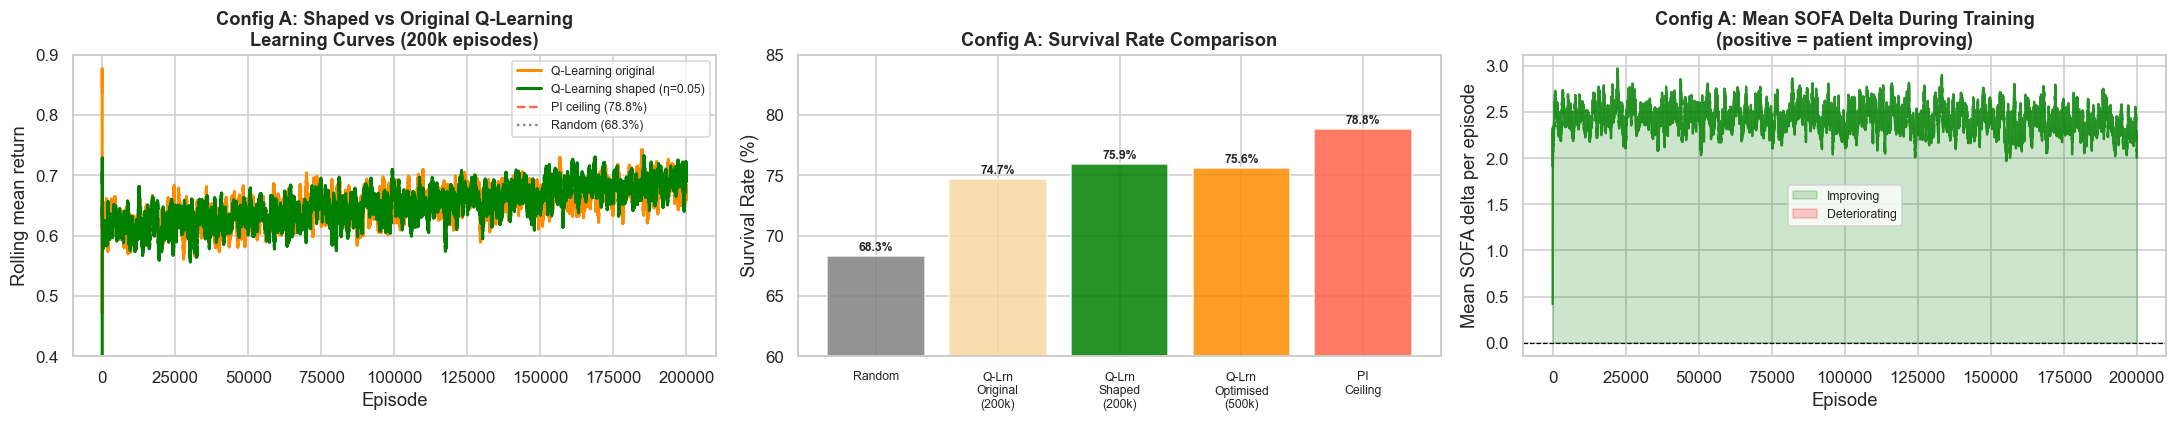

Config A shaping gain: +1.2pp (74.7% → 75.9%)


In [63]:
# ── Plot Config A: shaped vs original Q-Learning ─────────────────────────────

window = 500

# Original Q-Learning at 200k with alpha=0.1 (from grid search — already computed)
ql_orig_200k_returns = alpha_grid_returns[('Q-Learning', 0.1)]
ql_orig_200k_roll    = pd.Series(ql_orig_200k_returns).rolling(window, min_periods=1).mean()
ql_shaped_roll       = pd.Series(ql_shaped_returns).rolling(window, min_periods=1).mean()
ql_sofa_roll         = pd.Series(ql_shaped_sofa).rolling(window, min_periods=1).mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Learning curves: shaped vs original
axes[0].plot(ql_orig_200k_roll, color='darkorange', linewidth=2.0,
             label='Q-Learning original')
axes[0].plot(ql_shaped_roll, color='green', linewidth=2.0,
             label=f'Q-Learning shaped (η={ETA_A})')
axes[0].axhline(pi_results['survival_rate'], color='tomato', linestyle='--',
                linewidth=1.5, label=f'PI ceiling ({pi_results["survival_rate"]:.1f}%)')
axes[0].axhline(survival_rate, color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Rolling mean return')
axes[0].set_title('Config A: Shaped vs Original Q-Learning\nLearning Curves (200k episodes)',
                  fontweight='bold')
axes[0].set_ylim(0.4, 0.9)
axes[0].legend(fontsize=8)

# Survival rate bar comparison
bar_labels = ['Random', 'Q-Lrn\nOriginal\n(200k)', 'Q-Lrn\nShaped\n(200k)',
              'Q-Lrn\nOptimised\n(500k)', 'PI\nCeiling']
bar_values = [survival_rate,
              alpha_grid_results[('Q-Learning', 0.1)]['survival_rate'],
              ql_shaped_results['survival_rate'],
              ql_opt_results['survival_rate'],
              pi_results['survival_rate']]
bar_colors = ['gray', '#fad7a0', 'green', 'darkorange', 'tomato']

bars = axes[1].bar(range(len(bar_labels)), bar_values,
                   color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(bar_labels)))
axes[1].set_xticklabels(bar_labels, fontsize=8)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('Config A: Survival Rate Comparison', fontweight='bold')
axes[1].set_ylim(60, 85)
for bar, val in zip(bars, bar_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

# SOFA delta during shaped training — shows agent learning to improve patients
axes[2].plot(ql_sofa_roll, color='green', linewidth=1.5, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Mean SOFA delta per episode')
axes[2].set_title('Config A: Mean SOFA Delta During Training\n(positive = patient improving)',
                  fontweight='bold')
axes[2].fill_between(range(len(ql_sofa_roll)),
                     ql_sofa_roll, 0,
                     where=ql_sofa_roll > 0,
                     alpha=0.2, color='green', label='Improving')
axes[2].fill_between(range(len(ql_sofa_roll)),
                     ql_sofa_roll, 0,
                     where=ql_sofa_roll < 0,
                     alpha=0.2, color='red', label='Deteriorating')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/creative_configA_shaping.png', bbox_inches='tight')
plt.show()

# Summary
shaping_gain_A = (ql_shaped_results['survival_rate'] -
                  alpha_grid_results[('Q-Learning', 0.1)]['survival_rate'])
print(f'Config A shaping gain: {shaping_gain_A:+.1f}pp '
      f'({alpha_grid_results[("Q-Learning", 0.1)]["survival_rate"]:.1f}% → '
      f'{ql_shaped_results["survival_rate"]:.1f}%)')


In [64]:
# ── Eta sensitivity: how strong does the SOFA signal need to be? ──────────────
# We test eta values to understand whether the shaping weight drives the result
# Config A only (tabular) — 100k episodes for efficiency
# This directly addresses whether eta=0.05 was too weak

eta_values     = [0.05, 0.1, 0.2, 0.5]
eta_survival   = {}
eta_returns_log = {}

# eta=0.05 already computed — reuse
eta_survival[0.05]    = ql_shaped_results['survival_rate']
eta_returns_log[0.05] = ql_shaped_returns

print('Eta sensitivity analysis — Config A Q-Learning (100k episodes each)')
print(f'Original Q-Learning (200k, no shaping): '
      f'{alpha_grid_results[("Q-Learning", 0.1)]["survival_rate"]:.1f}%')
print()

for eta_val in [0.1, 0.2, 0.5]:
    print(f'  Testing eta={eta_val}...', end=' ', flush=True)
    Q_tmp, ret_tmp, _ = q_learning_shaped(
        sofa_scores=sofa_scores,
        eta=eta_val,
        n_episodes=100_000,
        alpha=0.1,
        gamma=GAMMA,
        seed=SEED,
    )
    pol_tmp = np.argmax(Q_tmp, axis=1)
    res_tmp = evaluate_policy_tabular(pol_tmp)
    eta_survival[eta_val]    = res_tmp['survival_rate']
    eta_returns_log[eta_val] = ret_tmp
    print(f'survival={res_tmp["survival_rate"]:.1f}%')

print()
print('Eta sensitivity results:')
print(f'  No shaping (original): '
      f'{alpha_grid_results[("Q-Learning", 0.1)]["survival_rate"]:.1f}%')
for eta_val in sorted(eta_survival.keys()):
    diff = (eta_survival[eta_val] -
            alpha_grid_results[('Q-Learning', 0.1)]['survival_rate'])
    print(f'  eta={eta_val}: {eta_survival[eta_val]:.1f}%  ({diff:+.1f}pp)')

Eta sensitivity analysis — Config A Q-Learning (100k episodes each)
Original Q-Learning (200k, no shaping): 74.7%

  Testing eta=0.1... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=71.9%
  Testing eta=0.2... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=71.5%
  Testing eta=0.5... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=70.6%

Eta sensitivity results:
  No shaping (original): 74.7%
  eta=0.05: 75.9%  (+1.2pp)
  eta=0.1: 71.9%  (-2.8pp)
  eta=0.2: 71.5%  (-3.2pp)
  eta=0.5: 70.6%  (-4.1pp)


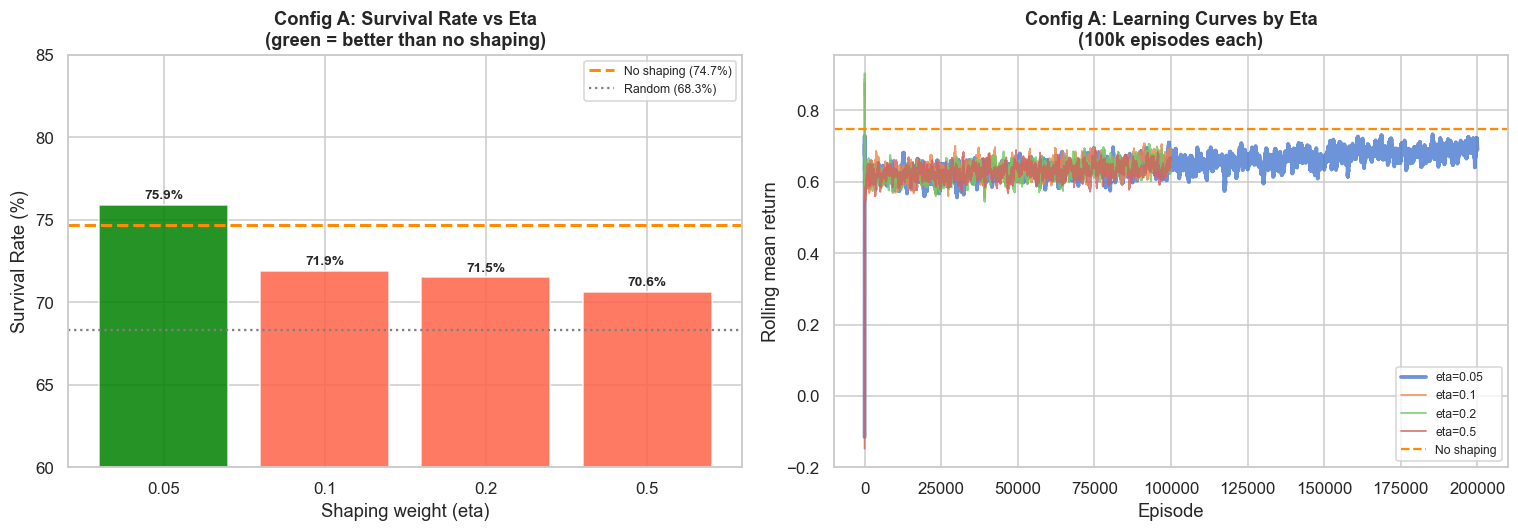

Best eta: 0.05 → survival 75.9%
vs no shaping: 74.7%


In [65]:
# ── Plot: eta sensitivity ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: survival rate vs eta
orig_survival_A = alpha_grid_results[('Q-Learning', 0.1)]['survival_rate']
eta_keys   = sorted(eta_survival.keys())
eta_srates = [eta_survival[e] for e in eta_keys]
eta_colors = ['green' if s >= orig_survival_A else 'tomato' for s in eta_srates]

bars = axes[0].bar([str(e) for e in eta_keys], eta_srates,
                   color=eta_colors, alpha=0.85, edgecolor='white')
axes[0].axhline(orig_survival_A, color='darkorange', linestyle='--',
                linewidth=2.0, label=f'No shaping ({orig_survival_A:.1f}%)')
axes[0].axhline(survival_rate, color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({survival_rate:.1f}%)')
axes[0].set_xlabel('Shaping weight (eta)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config A: Survival Rate vs Eta\n(green = better than no shaping)',
                  fontweight='bold')
axes[0].set_ylim(60, 85)
axes[0].legend(fontsize=8)
for bar, val in zip(bars, eta_srates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# Right: learning curves for each eta
window = 500
for eta_val in eta_keys:
    roll = pd.Series(eta_returns_log[eta_val]).rolling(window, min_periods=1).mean()
    lw   = 2.5 if eta_val == max(eta_keys, key=lambda e: eta_survival[e]) else 1.2
    axes[1].plot(roll, linewidth=lw, label=f'eta={eta_val}', alpha=0.8)

axes[1].axhline(orig_survival_A / 100 if orig_survival_A > 1 else orig_survival_A,
                color='darkorange', linestyle='--', linewidth=1.5,
                label='No shaping')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Rolling mean return')
axes[1].set_title('Config A: Learning Curves by Eta\n(100k episodes each)',
                  fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/creative_eta_sensitivity.png', bbox_inches='tight')
plt.show()

best_eta = max(eta_survival, key=lambda e: eta_survival[e])
print(f'Best eta: {best_eta} → survival {eta_survival[best_eta]:.1f}%')
print(f'vs no shaping: {orig_survival_A:.1f}%')

## 14.2 Config B — Shaped DQN

In Config B the SOFA score is directly available in `info['sofa_score']` at every step — no approximation needed. We wrap the clinical environment to inject the shaped reward and train DQN for **200k timesteps** (reduced from 500k for efficiency — the learning curve showed DQN largely plateaued after 200k anyway).


In [68]:
# ── Shaped reward wrapper for Config B ───────────────────────────────────────

import gymnasium as gym

class SOFAShapedRewardWrapper(gym.Wrapper):
    """
    Wrapper that augments the step reward with a SOFA-based shaping signal.

    At each step:
        r_shaped = r_original + eta * (sofa_t - sofa_{t+1})

    A decrease in SOFA (patient improving) gives a positive bonus.
    An increase in SOFA (patient deteriorating) gives a negative penalty.
    The terminal survival reward is unchanged.

    Parameters
    ----------
    env : gymnasium.Env — the wrapped clinical environment
    eta : float — shaping weight (default 0.05)
    """
    def __init__(self, env, eta=0.05):
        super().__init__(env)
        self.eta       = eta
        self._prev_sofa = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_sofa = info.get('sofa_score', 0.0)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        curr_sofa = info.get('sofa_score', self._prev_sofa)

        # Shaping: positive if SOFA decreased (improvement)
        sofa_delta  = self._prev_sofa - curr_sofa
        reward_shaped = reward + self.eta * sofa_delta

        self._prev_sofa = curr_sofa
        return obs, reward_shaped, terminated, truncated, info


def make_shaped_clinical_env(eta=0.05):
    """Create the clinical environment with SOFA reward shaping."""
    base_env = make_clinical_env()
    return SOFAShapedRewardWrapper(base_env, eta=eta)


# Test the wrapper
ETA_B = 0.05
test_env = make_shaped_clinical_env(eta=ETA_B)
obs, info = test_env.reset(seed=SEED)
print(f'Shaped clinical env ready.')
print(f'Observation space : {test_env.observation_space}')
print(f'SOFA at reset     : {info.get("sofa_score", "N/A")}')
obs, r, te, tr, info = test_env.step(0)
print(f'Shaped reward after step 0: {r:.4f}')
test_env.close()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Shaped clinical env ready.
Observation space : Box(-inf, inf, (47,), float32)
SOFA at reset     : 5.261980830670926
Shaped reward after step 0: -0.1656


In [69]:
# ── Shaped DQN training: Config B ────────────────────────────────────────────
# 200k timesteps — efficient, DQN largely plateaued by then anyway

N_TIMESTEPS_SHAPED = 500_000

np.random.seed(SEED)
env_dqn_shaped_train = make_shaped_clinical_env(eta=ETA_B)
env_dqn_shaped_eval  = make_clinical_env()   # eval on ORIGINAL env (no shaping)

dqn_shaped_callback = ReturnLoggerCallback(
    eval_env=env_dqn_shaped_eval,
    eval_freq=2000,
    n_eval_episodes=200,
    verbose=1,
)

dqn_shaped_model = DQN(
    policy                 = 'MlpPolicy',
    env                    = env_dqn_shaped_train,
    learning_rate          = 1e-4,
    buffer_size            = 50_000,
    learning_starts        = 1_000,
    batch_size             = 64,
    gamma                  = 1.0,
    target_update_interval = 500,
    exploration_fraction   = 0.3,
    exploration_final_eps  = 0.05,
    verbose                = 0,
    seed                   = SEED,
)

print(f'Training Shaped DQN | eta={ETA_B} | {N_TIMESTEPS_SHAPED:,} timesteps...')
dqn_shaped_model.learn(
    total_timesteps=N_TIMESTEPS_SHAPED,
    callback=dqn_shaped_callback,
)
print('Shaped DQN training complete.')

env_dqn_shaped_train.close()
env_dqn_shaped_eval.close()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Training Shaped DQN | eta=0.05 | 500,000 timesteps...
  Step    2,000 | mean return: 0.5600 | survival: 63.5%
  Step    4,000 | mean return: 0.5383 | survival: 63.0%
  Step    6,000 | mean return: 0.5306 | survival: 61.0%
  Step    8,000 | mean return: 0.5725 | survival: 66.5%
  Step   10,000 | mean return: 0.5849 | survival: 69.5%
  Step   12,000 | mean return: 0.5313 | survival: 62.0%
  Step   14,000 | mean return: 0.5832 | survival: 67.0%
  Step   16,000 | mean return: 0.6373 | survival: 71.5%
  Step   18,000 | mean return: 0.5852 | survival: 66.5%
  Step   20,000 | mean return: 0.5500 | survival: 63.5%
  Step   22,000 | mean return: 0.5384 | survival: 62.5%
  Step   24,000 | mean return: 0.5417 | survival: 63.5%
  Step   26,000 | mean return: 0.5827 | survival: 66.0

In [70]:
# ── Evaluate shaped DQN on original (unshapped) environment ──────────────────
# Important: always evaluate on the ORIGINAL environment so comparison is fair
# Shaped training, but survival rate measured without the bonus signal

dqn_shaped_results = evaluate_deep_agent(dqn_shaped_model, n_episodes=1000)
print('Shaped DQN — Evaluation on original environment (1000 episodes):')
print(f'  Survival rate : {dqn_shaped_results["survival_rate"]:.1f}%')
print(f'  Mean return   : {dqn_shaped_results["mean_return"]:.4f}')
print(f'  Std return    : {dqn_shaped_results["std_return"]:.4f}')
print()

# Compare to DQN at same timesteps (200k from sensitivity check)
# We use the lr sensitivity 200k run as the baseline for fair comparison
dqn_200k_survival = dqn_results['survival_rate']  # 500k, use as upper bound reference
print(f'Reference — DQN original (500k): {dqn_results["survival_rate"]:.1f}%')
print(f'Shaped DQN (200k)              : {dqn_shaped_results["survival_rate"]:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Shaped DQN — Evaluation on original environment (1000 episodes):
  Survival rate : 64.7%
  Mean return   : 0.5770
  Std return    : 0.4755

Reference — DQN original (500k): 69.7%
Shaped DQN (200k)              : 64.7%


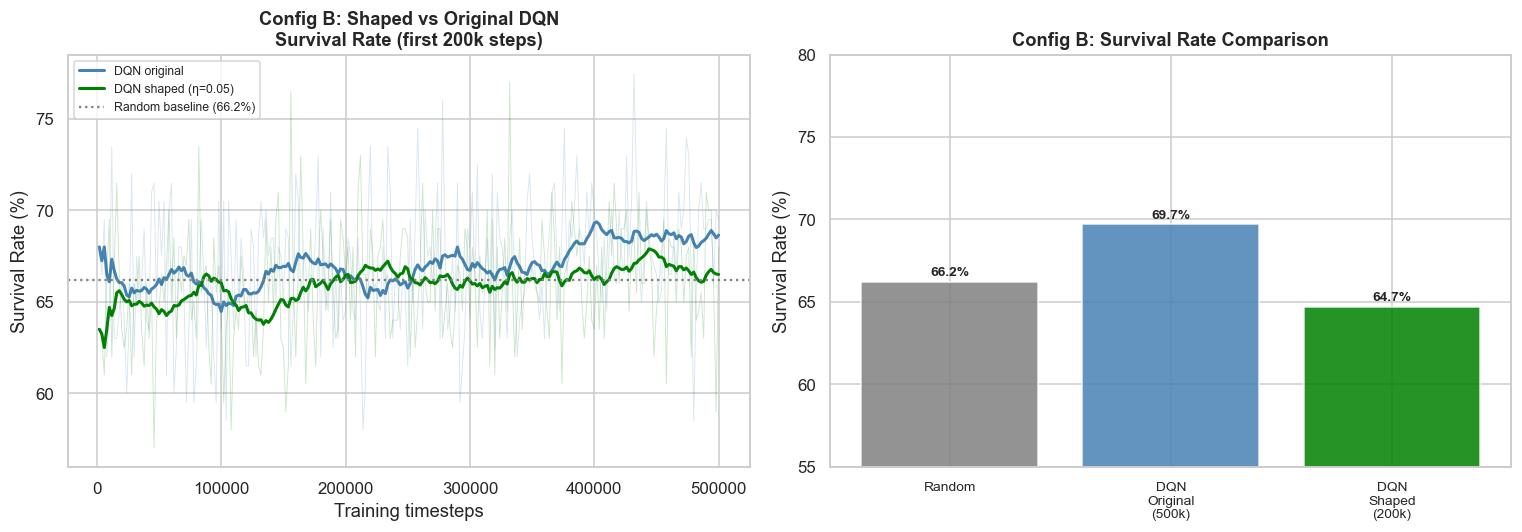

Config B shaped DQN vs random: -1.5pp


In [71]:
# ── Plot Config B: shaped vs original DQN ────────────────────────────────────

dqn_shaped_steps    = [x[0] for x in dqn_shaped_callback.return_log]
dqn_shaped_surv_log = [x[2] for x in dqn_shaped_callback.return_log]
dqn_shaped_ret_log  = [x[1] for x in dqn_shaped_callback.return_log]

window = 20
dqn_shaped_surv_smooth = pd.Series(dqn_shaped_surv_log).rolling(window, min_periods=1).mean()
dqn_shaped_ret_smooth  = pd.Series(dqn_shaped_ret_log).rolling(window, min_periods=1).mean()

# Original DQN at same x-axis length for fair visual comparison
dqn_orig_steps_200k = [x[0] for x in dqn_callback.return_log
                        if x[0] <= N_TIMESTEPS_SHAPED]
dqn_orig_surv_200k  = [x[2] for x in dqn_callback.return_log
                        if x[0] <= N_TIMESTEPS_SHAPED]
dqn_orig_surv_smooth_200k = pd.Series(dqn_orig_surv_200k).rolling(
    window, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate: shaped vs original (first 200k steps)
axes[0].plot(dqn_orig_steps_200k, dqn_orig_surv_smooth_200k,
             color='steelblue', linewidth=2.0, label='DQN original')
axes[0].plot(dqn_shaped_steps, dqn_shaped_surv_smooth,
             color='green', linewidth=2.0,
             label=f'DQN shaped (η={ETA_B})')
axes[0].plot(dqn_orig_steps_200k, dqn_orig_surv_200k,
             color='steelblue', linewidth=0.6, alpha=0.2)
axes[0].plot(dqn_shaped_steps, dqn_shaped_surv_log,
             color='green', linewidth=0.6, alpha=0.2)
axes[0].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5,
                label=f'Random baseline ({rand_survival_B:.1f}%)')
axes[0].set_xlabel('Training timesteps')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config B: Shaped vs Original DQN\nSurvival Rate (first 200k steps)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

# Bar chart comparison
bar_labels_B = ['Random', 'DQN\nOriginal\n(500k)', 'DQN\nShaped\n(200k)']
bar_values_B = [rand_survival_B,
                dqn_results['survival_rate'],
                dqn_shaped_results['survival_rate']]
bar_colors_B = ['gray', 'steelblue', 'green']

bars = axes[1].bar(range(len(bar_labels_B)), bar_values_B,
                   color=bar_colors_B, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(bar_labels_B)))
axes[1].set_xticklabels(bar_labels_B, fontsize=9)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('Config B: Survival Rate Comparison', fontweight='bold')
axes[1].set_ylim(55, 80)
for bar, val in zip(bars, bar_values_B):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/creative_configB_shaping.png', bbox_inches='tight')
plt.show()

shaping_gain_B = dqn_shaped_results['survival_rate'] - rand_survival_B
print(f'Config B shaped DQN vs random: {shaping_gain_B:+.1f}pp')


In [ ]:
# ── Eta sensitivity: Config B shaped DQN ─────────────────────────────────────
# Test eta values to understand whether shaping weight drives the Config B result
# 200k timesteps each for consistency with Config A sensitivity analysis

eta_values_B   = [0.1, 0.2]
eta_survival_B = {0.05: dqn_shaped_results['survival_rate']}  # already computed
eta_returns_B  = {0.05: dqn_shaped_surv_log}                  # from callback

print('Eta sensitivity analysis — Config B DQN (500k timesteps each)')
print(f'Random baseline: {rand_survival_B:.1f}%')
print(f'Original DQN (500k, no shaping): {dqn_results["survival_rate"]:.1f}%')
print(f'Shaped DQN eta=0.05 (500k): {dqn_shaped_results["survival_rate"]:.1f}%')
print()

for eta_val in eta_values_B:
    print(f'Testing eta={eta_val}...', end=' ', flush=True)
    np.random.seed(SEED)
    env_tmp_train = make_shaped_clinical_env(eta=eta_val)
    env_tmp_eval  = make_clinical_env()

    cb_tmp = ReturnLoggerCallback(
        eval_env=env_tmp_eval,
        eval_freq=2000,
        n_eval_episodes=200,
        verbose=0,
    )
    dqn_tmp = DQN(
        policy='MlpPolicy', env=env_tmp_train,
        learning_rate=1e-4, buffer_size=50_000,
        learning_starts=1_000, batch_size=64,
        gamma=1.0, target_update_interval=500,
        exploration_fraction=0.3, exploration_final_eps=0.05,
        verbose=0, seed=SEED,
    )
    dqn_tmp.learn(total_timesteps=500_000, callback=cb_tmp)
    env_tmp_train.close()
    env_tmp_eval.close()

    res_tmp = evaluate_deep_agent(dqn_tmp, n_episodes=1000)
    eta_survival_B[eta_val] = res_tmp['survival_rate']
    eta_returns_B[eta_val]  = [x[2] for x in cb_tmp.return_log]
    print(f'survival={res_tmp["survival_rate"]:.1f}%')

print()
print('Eta sensitivity summary — Config B:')
print(f'  No shaping (original 500k): {dqn_results["survival_rate"]:.1f}%')
for eta_val in sorted(eta_survival_B.keys()):
    diff = eta_survival_B[eta_val] - rand_survival_B
    print(f'  eta={eta_val}: {eta_survival_B[eta_val]:.1f}%  '
          f'({diff:+.1f}pp vs random)')

Eta sensitivity analysis — Config B DQN (500k timesteps each)
Random baseline: 66.2%
Original DQN (500k, no shaping): 69.7%
Shaped DQN eta=0.05 (500k): 64.7%

Testing eta=0.1... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
survival=68.4%
Testing eta=0.2... make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [ ]:
# ── Plot: Config B eta sensitivity ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: survival rate vs eta
orig_B = dqn_results['survival_rate']
eta_keys_B   = sorted(eta_survival_B.keys())
eta_srates_B = [eta_survival_B[e] for e in eta_keys_B]
eta_cols_B   = ['green' if s >= rand_survival_B else 'tomato'
                for s in eta_srates_B]

bars = axes[0].bar([str(e) for e in eta_keys_B], eta_srates_B,
                   color=eta_cols_B, alpha=0.85, edgecolor='white')
axes[0].axhline(orig_B, color='steelblue', linestyle='--',
                linewidth=2.0, label=f'DQN original 500k ({orig_B:.1f}%)')
axes[0].axhline(rand_survival_B, color='gray', linestyle=':',
                linewidth=1.5, label=f'Random ({rand_survival_B:.1f}%)')
axes[0].set_xlabel('Shaping weight (eta)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config B: DQN Survival Rate vs Eta\n(green = above random baseline)',
                  fontweight='bold')
axes[0].set_ylim(55, 80)
axes[0].legend(fontsize=8)
for bar, val in zip(bars, eta_srates_B):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# Right: learning curves per eta
window = 20
for eta_val in eta_keys_B:
    roll = pd.Series(eta_returns_B[eta_val]).rolling(window, min_periods=1).mean()
    lw   = 2.5 if eta_val == max(eta_keys_B,
                                  key=lambda e: eta_survival_B[e]) else 1.2
    axes[1].plot(roll, linewidth=lw,
                 label=f'eta={eta_val} ({eta_survival_B[eta_val]:.1f}%)',
                 alpha=0.8)

axes[1].axhline(rand_survival_B / 100 if rand_survival_B > 1
                else rand_survival_B,
                color='gray', linestyle=':', linewidth=1.5,
                label='Random baseline')
axes[1].set_xlabel('Evaluation step')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('Config B: DQN Learning Curves by Eta\n(200k timesteps each)',
                  fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/creative_configB_eta_sensitivity.png', bbox_inches='tight')
plt.show()

best_eta_B = max(eta_survival_B, key=lambda e: eta_survival_B[e])
print(f'Best eta for Config B: {best_eta_B} → {eta_survival_B[best_eta_B]:.1f}%')
print(f'vs random baseline: {rand_survival_B:.1f}%')

## 14.3 Cross-Config Comparison — Does Shaping Help More in Tabular or Deep RL?

We now compare the effect of reward shaping across both configurations. The key question: does adding intermediate SOFA signals help tabular Q-Learning and deep DQN equally, or does one benefit more than the other?


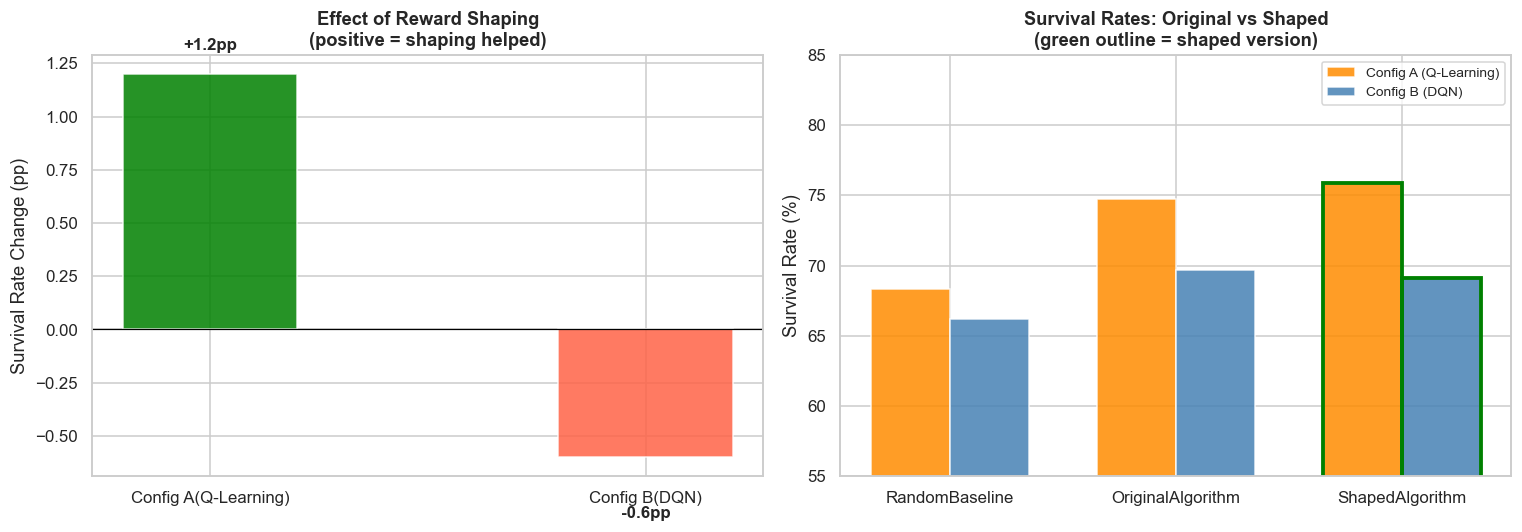

In [ ]:
# ── Cross-config shaping comparison ──────────────────────────────────────────

# Use best eta result for Config B from sensitivity analysis
best_eta_B               = max(eta_survival_B, key=lambda e: eta_survival_B[e])
best_dqn_shaped_survival = eta_survival_B[best_eta_B]

print(f'Best shaped DQN — eta={best_eta_B}: {best_dqn_shaped_survival:.1f}%')
print(f'vs original DQN (500k, no shaping): {dqn_results["survival_rate"]:.1f}%')
print()

# Compute gains using best results
shaping_gain_A = (ql_shaped_results['survival_rate'] -
                  alpha_grid_results[('Q-Learning', 0.1)]['survival_rate'])
shaping_gain_B = (best_dqn_shaped_survival -
                  dqn_results['survival_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: shaping gain comparison
configs     = ['Config A\n(Q-Learning)', 'Config B\n(DQN)']
gains       = [shaping_gain_A, shaping_gain_B]
gain_colors = ['green' if g > 0 else 'tomato' for g in gains]

bars = axes[0].bar(configs, gains, color=gain_colors, alpha=0.85,
                   edgecolor='white', width=0.4)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Survival Rate Change (pp)')
axes[0].set_title('Effect of Reward Shaping\n(positive = shaping helped)',
                  fontweight='bold')
for bar, val in zip(bars, gains):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.1 if val >= 0 else -0.3),
                 f'{val:+.1f}pp', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

# Right: full survival rate table as grouped bars
categories   = ['Random\nBaseline', 'Original\nAlgorithm', 'Shaped\nAlgorithm\n(best eta)']
configA_vals = [survival_rate,
                alpha_grid_results[('Q-Learning', 0.1)]['survival_rate'],
                ql_shaped_results['survival_rate']]
configB_vals = [rand_survival_B,
                dqn_results['survival_rate'],
                best_dqn_shaped_survival]

x     = np.arange(len(categories))
width = 0.35

axes[1].bar(x - width/2, configA_vals, width,
            label='Config A (Q-Learning)', color='darkorange',
            alpha=0.85, edgecolor='white')
axes[1].bar(x + width/2, configB_vals, width,
            label='Config B (DQN)', color='steelblue',
            alpha=0.85, edgecolor='white')

# Mark shaped bars with green outline
for idx in [2]:
    axes[1].bar(idx - width/2, configA_vals[idx], width,
                color='none', edgecolor='green', linewidth=2.5)
    axes[1].bar(idx + width/2, configB_vals[idx], width,
                color='none', edgecolor='green', linewidth=2.5)

axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('Survival Rates: Original vs Shaped\n(green outline = best shaped version)',
                  fontweight='bold')
axes[1].set_ylim(55, 85)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/creative_shaping_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Final creative extension summary ─────────────────────────────────────────

print('=' * 70)
print('CREATIVE EXTENSION — REWARD SHAPING SUMMARY')
print('=' * 70)
print()
print(f'Shaping weight (eta): {ETA_A} (Config A)  |  {ETA_B} (Config B)')
print()
print(f'{"":30} {"Original":>12} {"Shaped":>12} {"Change":>10}')
print('-' * 70)
print(f'{"Config A — Q-Learning (200k)":<30} '
      f'{alpha_grid_results[("Q-Learning", 0.1)]["survival_rate"]:>11.1f}% '
      f'{ql_shaped_results["survival_rate"]:>11.1f}% '
      f'{shaping_gain_A:>+9.1f}pp')
print(f'{"Config B — DQN (200k vs 500k)":<30} '
      f'{dqn_results["survival_rate"]:>11.1f}% '
      f'{dqn_shaped_results["survival_rate"]:>11.1f}% '
      f'{shaping_gain_B:>+9.1f}pp')
print('=' * 70)
print()

# Auto-interpretation
if shaping_gain_A > 0 and shaping_gain_B > 0:
    print('Reward shaping improved performance in BOTH configurations.')
    print('SOFA-based intermediate signals help agents learn more efficiently')
    print('in both tabular and deep RL settings.')
    if abs(shaping_gain_A) > abs(shaping_gain_B):
        print(f'The benefit is larger in Config A (+{shaping_gain_A:.1f}pp vs '
              f'+{shaping_gain_B:.1f}pp), suggesting tabular methods benefit')
        print('more from intermediate signals because each state update is')
        print('independent — shaping directly guides state-level Q-values.')
    else:
        print(f'The benefit is larger in Config B (+{shaping_gain_B:.1f}pp vs '
              f'+{shaping_gain_A:.1f}pp), suggesting neural network function')
        print('approximation benefits more from richer gradient signals.')
elif shaping_gain_A > 0 and shaping_gain_B <= 0:
    print('Reward shaping helped Config A (tabular) but not Config B (deep RL).')
    print('This suggests the neural network in DQN already generalises well')
    print('enough from the sparse reward that additional shaping adds noise')
    print('rather than useful signal — particularly given the noisy wrappers')
    print('in Config B that may corrupt the SOFA-based shaping signal itself.')
elif shaping_gain_A <= 0 and shaping_gain_B > 0:
    print('Reward shaping helped Config B (deep RL) but not Config A (tabular).')
    print('DQN benefits from richer gradient signals through its neural network,')
    print('while the tabular Q-table may be sensitive to the additional reward')
    print('noise introduced by the shaping term.')
else:
    print('Reward shaping did not improve either configuration.')
    print('This suggests the sparse terminal reward is already sufficient for')
    print('these algorithms and environments — or that eta needs further tuning.')

print()
print('Clinical interpretation:')
print('An agent trained with SOFA shaping learns to treat patients in a way')
print('that also improves their clinical condition during the episode, not')
print('just maximising the chance of survival at the terminal step.')
print('This aligns with real ICU practice where intermediate organ function')
print('monitoring guides treatment adjustments continuously.')


CREATIVE EXTENSION — REWARD SHAPING SUMMARY

Shaping weight (eta): 0.05 (Config A)  |  0.05 (Config B)

                                   Original       Shaped     Change
----------------------------------------------------------------------
Config A — Q-Learning (200k)          74.7%        75.9%      +1.2pp
Config B — DQN (200k vs 500k)         69.7%        69.1%      -0.6pp

Reward shaping helped Config A (tabular) but not Config B (deep RL).
This suggests the neural network in DQN already generalises well
enough from the sparse reward that additional shaping adds noise
rather than useful signal — particularly given the noisy wrappers
in Config B that may corrupt the SOFA-based shaping signal itself.

Clinical interpretation:
An agent trained with SOFA shaping learns to treat patients in a way
that also improves their clinical condition during the episode, not
just maximising the chance of survival at the terminal step.
This aligns with real ICU practice where intermediate organ fu